# XGBoost auf Porto Seguro's Safe Driver Prediction

Anwendung von XGBoost auf den Datensatz
[OpenML ID 42742](https://www.openml.org/search?type=data&status=active&id=42742).

**Reihenfolge**

1. Daten werden geladen und aufbereitet
2. Pipeline wird aufgebaut und mit Standardparametern trainiert
3. Einzelne Hyperparameter werden gezielt experimentell untersucht
4. Suchraum für die Hyperparameter wird festgelegt
5. Hyperparameter-Suche wird durchgeführt
6. Finales Modell wird trainiert und bewertet
7. Feature Importance auswerten

ROC-AUC bzw. den daraus abgeleiteten normalisierten
Gini-Koeffizienten (`2 · AUC − 1`) führe ich die Bewertung durch. Accuracy ist hier ungeeignet: nur etwa 3,6 % der
Beobachtungen gehören zur positiven Klasse, sodass ein Modell allein durch konstantes
Vorhersagen der Mehrheitsklasse über 96 % erreicht, ohne irgendeinen Nutzen zu haben (ggf. trotzdem pro forma als "bullshit"-Test durchführen)

## Import

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV,
)

from scipy.stats import randint, uniform, loguniform

from xgboost import XGBClassifier

import matplotlib as mpl
import matplotlib.pyplot as plt

### Konfiguration

Diese Konstanten steuern die Laufzeit. Zum Testen des Codes werden zunächst kleine Werte
festgelegt (`EXP_FRAC = 0.05`, `SEARCH_FRAC = 0.05`, `N_ITER = 5`)

In [2]:
mpl.style.use("seaborn-v0_8-colorblind")
RANDOM_STATE = 42

EXP_FRAC = 0.15      # Anteil der Trainingsdaten für die Experimente in Schritt 3
SEARCH_FRAC = 0.25   # Anteil der Trainingsdaten für die Hyperparameter-Suche
N_ITER = 30          # Anzahl gezogener Parameterkombinationen
CV_SPLITS = 3        # Folds innerhalb der Suche
CARD_LIMIT = 10      # Grenze One-Hot vs. Target-Encoding

## Ausgabeordner für Abbildungen und Tabellen

Abbildungen werden als PDF (Vektorformat) und PNG (300 dpi) gespeichert, Tabellen als CSV.
Das Nummernpräfix sorgt für eine stabile Sortierung im Ordner.

In [3]:
ABB_DIR = Path("xgboost_anwendung_abbildungen")
ABB_DIR.mkdir(exist_ok=True)


def save_fig(fig, name, formats=("pdf", "png"), dpi=300):
    """Speichert eine matplotlib-Figure in ABB_DIR in allen angegebenen Formaten."""
    pfade = []
    for fmt in formats:
        pfad = ABB_DIR / f"{name}.{fmt}"
        fig.savefig(pfad, format=fmt, dpi=dpi, bbox_inches="tight")
        pfade.append(str(pfad))
    print("gespeichert:", " | ".join(pfade))
    return pfade


def save_table(df, name, index=False, float_format="%.4f"):
    """Speichert einen DataFrame als CSV in ABB_DIR."""
    csv_pfad = ABB_DIR / f"{name}.csv"
    df.to_csv(csv_pfad, index=index, float_format=float_format)
    print("gespeichert:", csv_pfad)
    return [str(csv_pfad)]


print(f"Ausgabeordner: {ABB_DIR.resolve()}")

Ausgabeordner: C:\Users\ericz\ADA Projekt\xgboost_anwendung_abbildungen


## Schritt 1: Daten laden

In [4]:
df_raw = fetch_openml(data_id=42742, as_frame=True).frame

print(f"Rohdaten: {df_raw.shape[0]:,} Zeilen x {df_raw.shape[1]} Spalten")
df_raw.head()

Rohdaten: 595,212 Zeilen x 58 Spalten


,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0,2.0,2,5.0,1,0,0,1,0,0,...,9.0,1.0,5.0,8.0,0,1,1,0,0,1
1,0,1.0,1,7.0,0,0,0,0,1,0,...,3.0,1.0,1.0,9.0,0,1,1,0,1,0
2,0,5.0,4,9.0,1,0,0,0,1,0,...,4.0,2.0,7.0,7.0,0,1,1,0,1,0
3,0,0.0,1,2.0,0,0,1,0,0,0,...,2.0,2.0,4.0,9.0,0,0,0,0,0,0
4,0,0.0,2,0.0,1,0,1,0,0,0,...,3.0,1.0,1.0,3.0,0,0,0,1,1,0


### Zielvariable

Die Zielvariable wird robust nach `int` konvertiert, da OpenML sie je nach Version als
String, Categorical oder Float ausliefert.

In [5]:
df = df_raw.copy()
y = df.pop("target").astype(str).astype(float).astype(int)
X = df

verteilung = y.value_counts().sort_index()
print(verteilung)
print(f"\nPositivrate: {y.mean():.4%}")
print(f"Verhältnis negativ zu positiv: {verteilung[0] / verteilung[1]:.1f} : 1")

target
0    573518
1     21694
Name: count, dtype: int64

Positivrate: 3.6448%
Verhältnis negativ zu positiv: 26.4 : 1


gespeichert: xgboost_anwendung_abbildungen\01_zielverteilung.pdf | xgboost_anwendung_abbildungen\01_zielverteilung.png


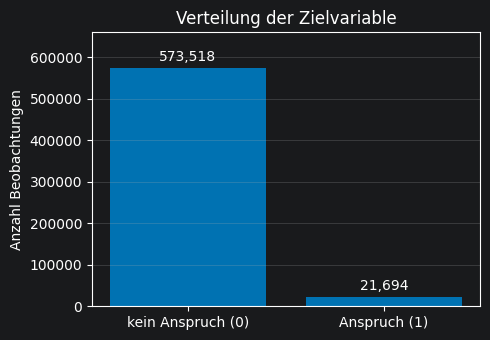

In [6]:
fig, ax = plt.subplots(figsize=(5, 3.5))
balken = ax.bar(["kein Anspruch (0)", "Anspruch (1)"], verteilung.values)
ax.bar_label(balken, fmt="{:,.0f}".format, padding=3)
ax.set_ylabel("Anzahl Beobachtungen")
ax.set_title("Verteilung der Zielvariable")
ax.set_ylim(0, verteilung.max() * 1.15)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

save_fig(fig, "01_zielverteilung")
plt.show()

### Feature-Typen und fehlende Werte

Der Datensatz kodiert den Merkmalstyp im Spaltennamen: das Suffix `_cat` steht für
kategorische, `_bin` für binäre Features; Spalten ohne Suffix sind kontinuierlich oder
ordinal.

Fehlende Werte sind als `-1` kodiert. Das ist für die Modellierung wichtig:

* Bei **numerischen** Features wird `-1` in `NaN` überführt. XGBoost lernt für jeden Split
  selbst, in welchen Kindknoten fehlende Werte laufen. Bliebe `-1` stehen, würde der
  Algorithmus es als gültigen Zahlenwert behandeln und darauf splitten, was die
  Baumstruktur verzerrt.
* Bei **kategorischen** Features bleibt `-1` als eigene Ausprägung erhalten. Dass eine
  Angabe fehlt, kann bei Versicherungsdaten selbst ein Signal sein, etwa bei
  unvollständig ausgefüllten Anträgen.

In [38]:
cat_cols = [c for c in X.columns if c.endswith("_cat")]
bin_cols = [c for c in X.columns if c.endswith("_bin")]
num_cols = [c for c in X.columns if c not in cat_cols + bin_cols]

X[num_cols] = X[num_cols].apply(pd.to_numeric, errors="coerce").replace(-1, np.nan)
X[bin_cols] = X[bin_cols].apply(pd.to_numeric, errors="coerce")
X[cat_cols] = X[cat_cols].astype(str)

# Kategorien mit vielen Ausprägungen werden später anders kodiert
high_card = [c for c in cat_cols if X[c].nunique() > CARD_LIMIT]
low_card = [c for c in cat_cols if c not in high_card]

print(f"numerisch/ordinal: {len(num_cols)} | binär: {len(bin_cols)} | "
      f"kategorisch: {len(cat_cols)}")
print(f"davon high-cardinality (> {CARD_LIMIT} Ausprägungen): {high_card}")

numerisch/ordinal: 26 | binär: 17 | kategorisch: 14
davon high-cardinality (> 10 Ausprägungen): ['ps_car_01_cat', 'ps_car_06_cat', 'ps_car_11_cat']


In [8]:
uebersicht = pd.DataFrame([
    {"Gruppe": "numerisch / ordinal", "Anzahl Features": len(num_cols),
     "mittlerer NaN-Anteil": X[num_cols].isna().mean().mean()},
    {"Gruppe": "binär (_bin)", "Anzahl Features": len(bin_cols),
     "mittlerer NaN-Anteil": X[bin_cols].isna().mean().mean()},
    {"Gruppe": f"kategorisch, <= {CARD_LIMIT} Ausprägungen",
     "Anzahl Features": len(low_card), "mittlerer NaN-Anteil": np.nan},
    {"Gruppe": f"kategorisch, > {CARD_LIMIT} Ausprägungen",
     "Anzahl Features": len(high_card), "mittlerer NaN-Anteil": np.nan},
])

save_table(uebersicht, "02_feature_uebersicht")
uebersicht

gespeichert: xgboost_anwendung_abbildungen\02_feature_uebersicht.csv


,Gruppe,Anzahl Features,mittlerer NaN-Anteil
0,numerisch / ordinal,26,0.009718
1,binär (_bin),17,0.000000
2,"kategorisch, <= 10 Ausprägungen",11,NaN
3,"kategorisch, > 10 Ausprägungen",3,NaN


gespeichert: xgboost_anwendung_abbildungen\03_fehlende_werte.pdf | xgboost_anwendung_abbildungen\03_fehlende_werte.png


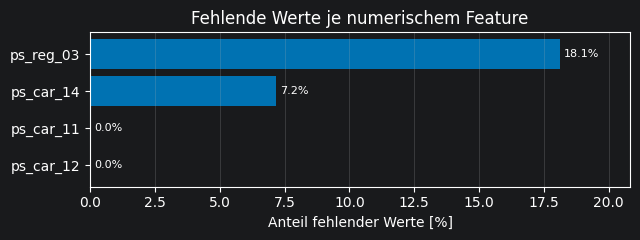

In [9]:
nan_anteil = X[num_cols + bin_cols].isna().mean()
nan_anteil = nan_anteil[nan_anteil > 0].sort_values(ascending=False)

if len(nan_anteil) > 0:
    fig, ax = plt.subplots(figsize=(6.5, max(2.5, 0.32 * len(nan_anteil))))
    balken = ax.barh(nan_anteil.index[::-1], nan_anteil.values[::-1] * 100)
    ax.bar_label(balken, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_xlabel("Anteil fehlender Werte [%]")
    ax.set_title("Fehlende Werte je numerischem Feature")
    ax.set_xlim(0, nan_anteil.max() * 115)
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()

    save_fig(fig, "03_fehlende_werte")
    plt.show()
else:
    print("Keine fehlenden Werte in den numerischen Features.")

In [39]:
for spalte in ["ps_reg_03", "ps_car_14"]:
    fehlt = X[spalte].isna()
    print(f"{spalte}: Positivrate wenn vorhanden {y[~fehlt].mean():.4%} | "
          f"wenn fehlend {y[fehlt].mean():.4%}")

ps_reg_03: Positivrate wenn vorhanden 3.8228% | wenn fehlend 2.8393%
ps_car_14: Positivrate wenn vorhanden 3.6141% | wenn fehlend 4.0427%


### Train/Test-Split

Der Split erfolgt **vor** jedem Encoding und vor der Hyperparameter-Suche, damit keine
Information aus den Testdaten in die Modellierung fließt. `stratify=y` erhält das stark
unausgewogene Klassenverhältnis in beiden Teilmengen — ohne Stratifizierung schwankt die
Schätzung der Metrik bei nur ~3,6 % positiven Fällen deutlich.

Der Testdatensatz wird ausschließlich am Ende verwendet. Alle Zwischenentscheidungen
fallen auf Basis der Cross-Validation innerhalb der Trainingsdaten.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape[0]:,} Zeilen | Positivrate {y_train.mean():.4%}")
print(f"Test:  {X_test.shape[0]:,} Zeilen | Positivrate {y_test.mean():.4%}")

Train: 476,169 Zeilen | Positivrate 3.6447%
Test:  119,043 Zeilen | Positivrate 3.6449%


## Schritt 2: Pipeline

Die gesamte Vorverarbeitung wird in einer Scikit-Learn-Pipeline gekapselt. Bei der Cross-Validation werden die Encoder dadurch automatisch pro Fold neu
gefittet. Würde man vorab auf dem gesamten Trainingssatz kodieren, flöße Information aus
den Validierungs-Folds in die Kodierung ein.

**Encoding-Strategie**

* **One-Hot** für kategorische Features mit wenigen Ausprägungen.
* **Target-Encoding** für `ps_car_11_cat` mit rund 100 Ausprägungen — One-Hot würde die
  Matrix hier unnötig aufblähen. Scikit-Learns `TargetEncoder` nutzt intern ein
  Cross-Fitting: die Kodierung einer Beobachtung wird aus Folds berechnet, die diese
  Beobachtung nicht enthalten. Ohne diesen Mechanismus kann bei hoher Kardinalität die
  Zielvariable in das Feature durchsickern.
* **Kein Scaling.** Baumbasierte Verfahren sind invariant gegenüber monotonen
  Transformationen einzelner Features. `StandardScaler` wäre hier wirkungslos.
* `sparse_threshold=0` erzwingt eine dichte Ausgabe, damit die `NaN`-Werte erhalten bleiben
  und XGBoost sie verarbeiten kann.
* `set_output(transform="pandas")` erhält die Spaltennamen, was für die Feature Importance
  in Schritt 7 gebraucht wird — sonst erscheinen dort nur `f0, f1, f2, …`.

Die Vorverarbeitung liegt in einer eigenen Funktion `baue_prep()`, weil sie in Schritt 3
auch einmal ohne Pipeline gebraucht wird (für Lernkurven mit `eval_set`).

In [11]:
BASIS_PARAMS = dict(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",       # deutlich schneller bei ~600k Zeilen
    n_jobs=-1,
    random_state=RANDOM_STATE,
)


def baue_prep():
    """Erzeugt den ColumnTransformer für die Vorverarbeitung."""
    return ColumnTransformer(
        transformers=[
            ("cat_low", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
             low_card),
            ("cat_high", TargetEncoder(target_type="binary", random_state=RANDOM_STATE),
             high_card),
            ("num", "passthrough", num_cols + bin_cols),
        ],
        remainder="drop",
        sparse_threshold=0,
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")


def baue_pipeline(**model_params):
    """Erzeugt eine Preprocessing+XGBoost-Pipeline.

    Keyword-Argumente überschreiben die Werte in BASIS_PARAMS.
    """
    return Pipeline([("prep", baue_prep()),
                     ("model", XGBClassifier(**{**BASIS_PARAMS, **model_params}))])


baue_pipeline()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_low', ...), ('cat_high', ...), ...]"
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` w

### Erster Durchlauf mit Standardparametern

Bevor optimiert wird, wird ein Durchlauf mit den Standardwerten von XGBoost durchgeführt. Das liefert einen
Bezugspunkt, an dem sich später ablesen lässt, wie viel die Hyperparameter-Optimierung
tatsächlich einbringt.

Der Abstand zwischen Trainings- und Test-AUC ist dabei der erste Hinweis auf Overfitting.

In [12]:
modell_standard = baue_pipeline()

t0 = time.perf_counter()
modell_standard.fit(X_train, y_train)
zeit_standard = time.perf_counter() - t0

proba_standard = modell_standard.predict_proba(X_test)[:, 1]
auc_standard = roc_auc_score(y_test, proba_standard)
auc_standard_train = roc_auc_score(y_train, modell_standard.predict_proba(X_train)[:, 1])

print(f"Fit-Zeit: {zeit_standard:.1f} s\n")
print(f"Train  AUC: {auc_standard_train:.4f}")
print(f"Test   AUC: {auc_standard:.4f} | Gini: {2 * auc_standard - 1:.4f}")
print(f"Abstand Train-Test: {auc_standard_train - auc_standard:.4f}")

C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Fit-Zeit: 10.1 s

Train  AUC: 0.7724
Test   AUC: 0.6133 | Gini: 0.2266
Abstand Train-Test: 0.1591


## Schritt 3: Experimente zur Wirkung einzelner Hyperparameter

Die Hyperparameter-Suche in Schritt 5 liefert am Ende nur eine Zahl: die beste gefundene
Kombination. Sie erklärt aber nicht, *warum* der Suchraum so gewählt wurde und was die
einzelnen Parameter überhaupt bewirken. Dieser Abschnitt schiebt deshalb gezielte
Einzelexperimente dazwischen — teilweise mit bewusst unsinnigen Werten, weil der
Wirkmechanismus an einem kaputten Modell besser sichtbar wird als an einem guten.

**Aufbau.** Es gibt eine feste Referenzkonfiguration. In jedem Experiment wird davon
genau *ein* Parameter verändert, alles andere bleibt gleich. Nur so ist der beobachtete
Effekt eindeutig zuordenbar.

**Laufzeit.** Die Experimente sind in drei Stufen sortiert, gemessen an der Dauer eines
Referenz-Fits:

| Stufe | relative Dauer | Inhalt |
|---|---|---|
| 0 | ca. 0,1–0,3 × | Konfigurationen, bei denen das Modell kollabiert |
| 1 | ca. 1 × | Parameter am Rand ihres sinnvollen Bereichs |
| 2 | ca. 3–10 × | Overfitting sichtbar machen, Komplexitätsreihe |

**Datengrundlage.** Alle Experimente laufen auf einer stratifizierten Teilmenge der
*Trainings*daten, die noch einmal in einen Experiment-Trainings- und einen
Experiment-Validierungsteil zerlegt wird. Der Testdatensatz aus Schritt 1 bleibt
unberührt.

In [13]:
X_exp, _, y_exp, _ = train_test_split(
    X_train, y_train, train_size=EXP_FRAC, stratify=y_train,
    random_state=RANDOM_STATE,
)
X_exp_tr, X_exp_val, y_exp_tr, y_exp_val = train_test_split(
    X_exp, y_exp, test_size=0.25, stratify=y_exp, random_state=RANDOM_STATE,
)

print(f"Experiment-Train: {X_exp_tr.shape[0]:,} Zeilen | "
      f"Positivrate {y_exp_tr.mean():.4%}")
print(f"Experiment-Val:   {X_exp_val.shape[0]:,} Zeilen | "
      f"Positivrate {y_exp_val.mean():.4%}")

Experiment-Train: 53,568 Zeilen | Positivrate 3.6440%
Experiment-Val:   17,857 Zeilen | Positivrate 3.6456%


### Referenzkonfiguration und Messfunktion

Die Referenz ist bewusst schlicht gewählt: mittlere Baumtiefe, moderate Lernrate,
überschaubare Baumzahl. Sie soll kein gutes Modell sein, sondern ein stabiler
Vergleichspunkt.

`experiment()` trainiert eine Variante, misst Train- und Validierungs-AUC sowie die
Laufzeit und hängt das Ergebnis an eine gemeinsame Liste an. Am Ende von Schritt 3 wird
daraus eine Tabelle.

In [14]:
REF_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    min_child_weight=10,
)

experimente = []


def experiment(name, stufe, hypothese, **override):
    """Trainiert eine Variante der Referenzkonfiguration und protokolliert das Ergebnis."""
    pipe = baue_pipeline(**{**REF_PARAMS, **override})

    t0 = time.perf_counter()
    pipe.fit(X_exp_tr, y_exp_tr)
    dauer = time.perf_counter() - t0

    auc_tr = roc_auc_score(y_exp_tr, pipe.predict_proba(X_exp_tr)[:, 1])
    auc_val = roc_auc_score(y_exp_val, pipe.predict_proba(X_exp_val)[:, 1])

    experimente.append({
        "Stufe": stufe,
        "Konfiguration": name,
        "Hypothese": hypothese,
        "AUC Train": auc_tr,
        "AUC Val": auc_val,
        "Gini Val": 2 * auc_val - 1,
        "Abstand": auc_tr - auc_val,
        "Zeit [s]": dauer,
    })
    print(f"{name:<26} Train {auc_tr:.4f} | Val {auc_val:.4f} | "
          f"Abstand {auc_tr - auc_val:+.4f} | {dauer:6.1f} s")
    return pipe


pipe_ref = experiment("Referenz", 0, "Vergleichspunkt für alle weiteren Läufe")

C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Referenz                   Train 0.8419 | Val 0.5959 | Abstand +0.2460 |    2.6 s


### Stufe 0 — Regularisierung bis zum Anschlag

Diese Läufe sind schneller als die Referenz, weil die Bäume gar nicht erst wachsen. Drei
völlig verschiedene Parameter setzen dabei an drei verschiedenen Stellen an:

* **`gamma`** ist die Mindestverbesserung, die ein Split bringen muss. Ein absurd hoher
  Wert bedeutet: kein Split wird je akzeptiert, jeder Baum bleibt ein einzelnes Blatt.
  Das Modell sagt für alle Beobachtungen denselben Wert vorher, die AUC ist damit exakt
  0,5.
* **`min_child_weight`** ist die Mindestsumme der Hessian-Werte pro Blatt. Bei
  logistischer Verlustfunktion ist der Hessian-Beitrag einer Beobachtung `p·(1−p)`. Die
  folgende Zelle berechnet die Gesamtsumme im Wurzelknoten — liegt die Schwelle darüber,
  ist von vornherein kein Split möglich. Ergebnis: derselbe Kollaps wie bei `gamma`, über
  einen völlig anderen Mechanismus.
* **`reg_lambda`** bestraft die Blattgewichte quadratisch. Hier ist das Ergebnis
  *anders*, und das ist der lehrreiche Teil: die Bäume werden weiterhin gebaut, nur die
  Gewichte werden stark gestaucht. Da alle Gewichte ungefähr im gleichen Verhältnis
  schrumpfen, bleibt die **Rangfolge** der Vorhersagen weitgehend erhalten — und die AUC
  misst genau nur diese Rangfolge. Der Wert bricht also ein, landet aber nicht bei 0,5.
  Eine metrische Bewertung wie Log-Loss würde denselben Lauf viel härter abstrafen.

Der vierte Lauf, `max_depth = 1`, ist kein Kollaps. Ein Baum mit einem einzigen Split
kann keine Wechselwirkungen zwischen Features abbilden, das Modell ist also rein additiv.
Wie nah dieser Wert an der Referenz liegt, ist ein direkter Hinweis darauf, wie viel
Signal in diesem Datensatz überhaupt aus Feature-Interaktionen stammt.

In [15]:
p0 = y_exp_tr.mean()
hessian_summe = len(y_exp_tr) * p0 * (1 - p0)
print(f"Summe der Hessian-Werte im Wurzelknoten: {hessian_summe:,.0f}")
print(f"-> min_child_weight oberhalb dieses Werts verhindert jeden Split.\n")

experiment("gamma = 1000",            0, "kein Split erfüllt die Gain-Schwelle",
           gamma=1000)
experiment("min_child_weight = 1e6",  0, "kein Blatt erreicht die Hessian-Schwelle",
           min_child_weight=1e6)
experiment("reg_lambda = 1e6",        0, "Blattgewichte werden gegen null gedrückt",
           reg_lambda=1e6)
experiment("max_depth = 1",           0, "additives Modell ohne Feature-Interaktionen",
           max_depth=1)

Summe der Hessian-Werte im Wurzelknoten: 1,881
-> min_child_weight oberhalb dieses Werts verhindert jeden Split.



C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


gamma = 1000               Train 0.5000 | Val 0.5000 | Abstand +0.0000 |    1.5 s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


min_child_weight = 1e6     Train 0.5000 | Val 0.5000 | Abstand +0.0000 |    1.9 s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


reg_lambda = 1e6           Train 0.5936 | Val 0.5943 | Abstand -0.0007 |    1.9 s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


max_depth = 1              Train 0.6457 | Val 0.6279 | Abstand +0.0178 |    1.4 s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['ps_ind_01','ps_ind_02_cat','ps_ind_03',...,'ps_calc_18_bin', 'ps_calc_19_bin','ps_calc_20_bin']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_low', ...), ('cat_high', ...), ...]"
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always return

#### Warum Accuracy hier keine brauchbare Metrik ist

Das kollabierte Modell eignet sich, um die Metrikwahl aus der Einleitung zu belegen.
`predict()` wendet die feste Schwelle 0,5 auf die vorhergesagten Wahrscheinlichkeiten an.
Bei einer Positivrate von 3,6 % liegen fast alle Vorhersagen darunter, sodass das Modell
praktisch durchgehend „kein Anspruch" ausgibt — bei perfekter Kollaps-Konfiguration sogar
ausnahmslos.

In [16]:
modell_kollaps = baue_pipeline(**{**REF_PARAMS, "gamma": 1000})
modell_kollaps.fit(X_exp_tr, y_exp_tr)

for label, modell in [("kollabiert (gamma=1000)", modell_kollaps),
                      ("Referenz", pipe_ref)]:
    pred_hart = modell.predict(X_exp_val)
    proba = modell.predict_proba(X_exp_val)[:, 1]
    print(f"{label}")
    print(f"  Anteil vorhergesagter positiver Fälle: {pred_hart.mean():.4%}")
    print(f"  Accuracy: {(pred_hart == y_exp_val).mean():.4%}  <- irreführend hoch")
    print(f"  ROC-AUC:  {roc_auc_score(y_exp_val, proba):.4f}  <- aussagekräftig\n")

print(f"Tatsächlicher Anteil positiver Fälle: {y_exp_val.mean():.4%}")

C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


kollabiert (gamma=1000)
  Anteil vorhergesagter positiver Fälle: 0.0000%
  Accuracy: 96.3544%  <- irreführend hoch
  ROC-AUC:  0.5000  <- aussagekräftig

Referenz
  Anteil vorhergesagter positiver Fälle: 0.0000%
  Accuracy: 96.3544%  <- irreführend hoch
  ROC-AUC:  0.5959  <- aussagekräftig

Tatsächlicher Anteil positiver Fälle: 3.6456%


### Stufe 1 — Parameter am Rand ihres sinnvollen Bereichs

Diese Läufe kosten ungefähr so viel wie die Referenz.

* **`learning_rate = 0.001`** bei gleichbleibend 300 Bäumen: die Schrittweite ist so
  klein, dass das Modell nach 300 Runden noch weit vom Optimum entfernt ist —
  klassischer Underfit durch ein abgeschnittenes Training.
* **`learning_rate = 1.0`**: jeder Baum korrigiert den vollen Residualschritt. Das
  Verfahren wird instabil und überspringt gute Zwischenzustände.
* **`subsample = 0.05`**: jeder Baum sieht nur 5 % der Zeilen. Bei 3,6 % Positivrate sind
  das entsprechend wenige positive Fälle pro Baum.
* **`colsample_bytree = 0.05`**: jeder Baum bekommt nur eine Handvoll Features zu sehen.
* **`scale_pos_weight`**: gewichtet die Minderheitsklasse hoch. Der oft erwartete große
  Gewinn bleibt aus — die AUC hängt nur von der *Rangfolge* der Vorhersagen ab, und die
  wird durch eine gleichmäßige Umgewichtung im Kern nicht besser. Massiv verschoben wird
  dagegen die Skala der Wahrscheinlichkeiten (siehe Abbildung unten).
  Ein Nebeneffekt ist trotzdem zu erwarten: mit den Gewichten skalieren auch die
  Hessian-Werte, sodass `min_child_weight` faktisch lockerer wirkt und die Bäume anders
  wachsen. Ein Teil der beobachteten Differenz geht also auf dieses Konto und nicht auf
  die Umgewichtung als solche.

In [17]:
spw = (y_exp_tr == 0).sum() / (y_exp_tr == 1).sum()
print(f"scale_pos_weight aus dem Klassenverhältnis: {spw:.1f}\n")

experiment("learning_rate = 0.001",   1, "Underfit, Training zu früh abgeschnitten",
           learning_rate=0.001)
experiment("learning_rate = 1.0",     1, "instabiles Training, überspringt Optimum",
           learning_rate=1.0)
experiment("subsample = 0.05",        1, "sehr wenige Beobachtungen je Baum",
           subsample=0.05)
experiment("colsample_bytree = 0.05", 1, "sehr wenige Features je Baum",
           colsample_bytree=0.05)
pipe_spw = experiment(f"scale_pos_weight = {spw:.0f}", 1,
                      "AUC unverändert, Wahrscheinlichkeiten verschoben",
                      scale_pos_weight=spw)

scale_pos_weight aus dem Klassenverhältnis: 26.4



C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


learning_rate = 0.001      Train 0.6424 | Val 0.6188 | Abstand +0.0236 |    1.9 s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


learning_rate = 1.0        Train 0.9838 | Val 0.5181 | Abstand +0.4657 |    1.8 s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


subsample = 0.05           Train 0.6546 | Val 0.5725 | Abstand +0.0821 |    1.9 s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


colsample_bytree = 0.05    Train 0.7280 | Val 0.6121 | Abstand +0.1159 |    1.7 s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


scale_pos_weight = 26      Train 0.8858 | Val 0.5827 | Abstand +0.3031 |    1.7 s


#### Wirkung von `scale_pos_weight` auf die Wahrscheinlichkeiten

Die beiden Histogramme zeigen dieselben Beobachtungen, bewertet von zwei Modellen, die
sich nur in `scale_pos_weight` unterscheiden. Der AUC-Unterschied in der Tabelle oben ist
minimal, die Verteilung der ausgegebenen Wahrscheinlichkeiten dagegen völlig verschieden.

Praktische Folge: Wenn aus dem Modell später Erwartungswerte abgeleitet werden sollen —
bei einer Versicherung etwa eine Schadenerwartung als Prämienbestandteil —, ist die
gewichtete Variante ohne Rekalibrierung unbrauchbar, obwohl ihre AUC gleich gut aussieht.

gespeichert: xgboost_anwendung_abbildungen\04_scale_pos_weight.pdf | xgboost_anwendung_abbildungen\04_scale_pos_weight.png


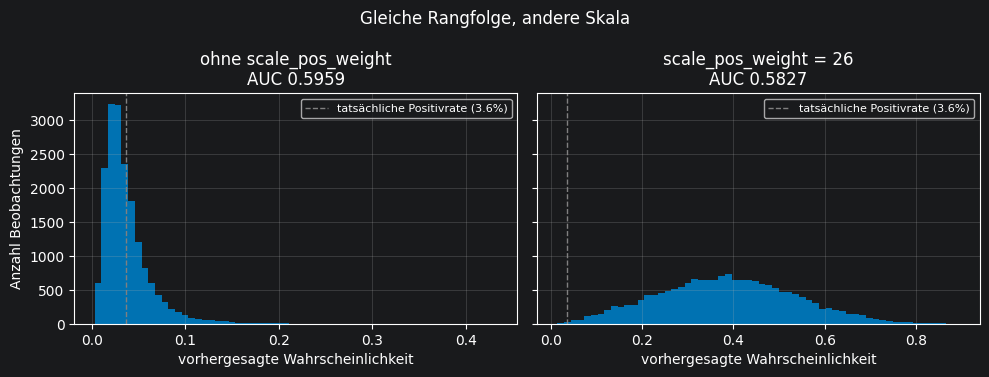

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)

for ax, (label, modell) in zip(axes, [("ohne scale_pos_weight", pipe_ref),
                                      (f"scale_pos_weight = {spw:.0f}", pipe_spw)]):
    proba = modell.predict_proba(X_exp_val)[:, 1]
    ax.hist(proba, bins=60)
    ax.axvline(y_exp_val.mean(), color="grey", linestyle="--", linewidth=1,
               label=f"tatsächliche Positivrate ({y_exp_val.mean():.1%})")
    ax.set_xlabel("vorhergesagte Wahrscheinlichkeit")
    ax.set_title(f"{label}\nAUC {roc_auc_score(y_exp_val, proba):.4f}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Anzahl Beobachtungen")
fig.suptitle("Gleiche Rangfolge, andere Skala")
fig.tight_layout()

save_fig(fig, "04_scale_pos_weight")
plt.show()

### Stufe 2 — Overfitting sichtbar machen

Hier fängt das Warten an. Zwei Experimente:

**(a) Lernkurve über die Boosting-Runden.** Alle Bremsen werden gleichzeitig gelöst:
tiefe Bäume, hohe Lernrate, keine Regularisierung, kein Early Stopping. Über `eval_set`
protokolliert XGBoost nach jeder Runde die AUC auf Trainings- und Validierungsdaten. Die
beiden Kurven gegeneinander geplottet ergeben die typische Schere — Train läuft weiter
nach oben, Validierung erreicht früh ihr Maximum und fällt danach.

Für `eval_set` muss die Vorverarbeitung von Hand angewendet werden: eine
Scikit-Learn-Pipeline reicht `eval_set` unverändert an das Modell durch, ohne die darin
enthaltenen Daten zu transformieren. Der Encoder wird ausschließlich auf den
Trainingsdaten gefittet, die Validierungsdaten werden nur transformiert.

In [19]:
prep_exp = baue_prep()
X_exp_tr_enc = prep_exp.fit_transform(X_exp_tr, y_exp_tr)
X_exp_val_enc = prep_exp.transform(X_exp_val)

print(f"nach Encoding: {X_exp_tr_enc.shape[1]} Spalten")

modell_overfit = XGBClassifier(
    **BASIS_PARAMS,
    n_estimators=1200,
    learning_rate=0.3,
    max_depth=12,
    min_child_weight=1,
    gamma=0,
    reg_lambda=0,
)

t0 = time.perf_counter()
modell_overfit.fit(
    X_exp_tr_enc, y_exp_tr,
    eval_set=[(X_exp_tr_enc, y_exp_tr), (X_exp_val_enc, y_exp_val)],
    verbose=200,
)
print(f"\nDauer: {(time.perf_counter() - t0) / 60:.1f} min")

C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


nach Encoding: 95 Spalten
[0]	validation_0-auc:0.81957	validation_1-auc:0.52735
[200]	validation_0-auc:1.00000	validation_1-auc:0.56653
[400]	validation_0-auc:1.00000	validation_1-auc:0.56792
[600]	validation_0-auc:1.00000	validation_1-auc:0.56453
[800]	validation_0-auc:1.00000	validation_1-auc:0.56176
[1000]	validation_0-auc:1.00000	validation_1-auc:0.56103
[1199]	validation_0-auc:1.00000	validation_1-auc:0.56058

Dauer: 0.6 min


gespeichert: xgboost_anwendung_abbildungen\05_overfitting_lernkurve.pdf | xgboost_anwendung_abbildungen\05_overfitting_lernkurve.png


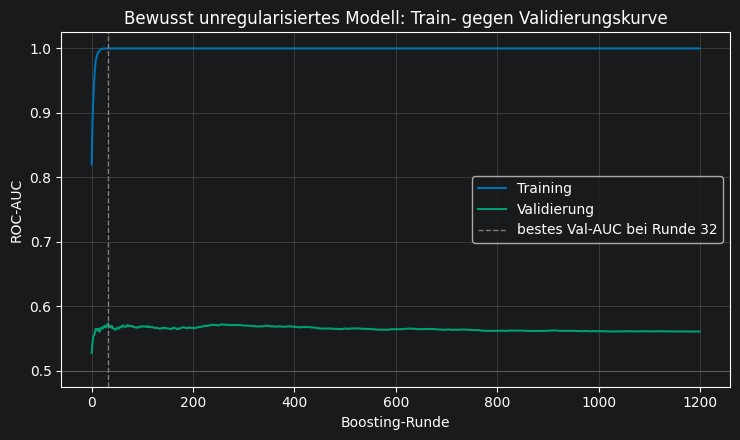

bestes Validierungs-AUC: 0.5733 bei Runde 32
Validierungs-AUC am Ende (Runde 1199): 0.5606
Train-AUC am Ende: 1.0000

Verlust durch Weitertrainieren nach dem Optimum: 0.0127 AUC


In [20]:
verlauf = modell_overfit.evals_result()
auc_tr_kurve = np.array(verlauf["validation_0"]["auc"])
auc_val_kurve = np.array(verlauf["validation_1"]["auc"])
runde_best = int(np.argmax(auc_val_kurve))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(auc_tr_kurve, label="Training", linewidth=1.5)
ax.plot(auc_val_kurve, label="Validierung", linewidth=1.5)
ax.axvline(runde_best, color="grey", linestyle="--", linewidth=1,
           label=f"bestes Val-AUC bei Runde {runde_best}")
ax.axhline(0.5, color="grey", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Boosting-Runde")
ax.set_ylabel("ROC-AUC")
ax.set_title("Bewusst unregularisiertes Modell: Train- gegen Validierungskurve")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

save_fig(fig, "05_overfitting_lernkurve")
plt.show()

print(f"bestes Validierungs-AUC: {auc_val_kurve[runde_best]:.4f} bei Runde {runde_best}")
print(f"Validierungs-AUC am Ende (Runde {len(auc_val_kurve) - 1}): "
      f"{auc_val_kurve[-1]:.4f}")
print(f"Train-AUC am Ende: {auc_tr_kurve[-1]:.4f}")
print(f"\nVerlust durch Weitertrainieren nach dem Optimum: "
      f"{auc_val_kurve[runde_best] - auc_val_kurve[-1]:.4f} AUC")

**(b) Komplexitätsreihe über `max_depth`.** Derselbe Gedanke, nur entlang einer
einzelnen Achse. Alle anderen Parameter bleiben auf den Referenzwerten. Erwartung: der
Abstand zwischen Train- und Validierungs-AUC wächst monoton mit der Tiefe, während die
Validierungs-AUC ein Maximum durchläuft und danach wieder fällt.

Bei `tree_method="hist"` wächst die Laufzeit mit der Tiefe nicht mehr streng exponentiell,
`max_depth = 12` ist aber trotzdem spürbar langsamer als die Referenz.

In [21]:
for tiefe in [2, 6, 8, 10, 12]:
    experiment(f"max_depth = {tiefe}", 2,
               "Komplexitätsreihe: Overfitting-Verlauf über die Baumtiefe",
               max_depth=tiefe)

C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


max_depth = 2              Train 0.7004 | Val 0.6324 | Abstand +0.0679 |    2.4 s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


max_depth = 6              Train 0.9562 | Val 0.5887 | Abstand +0.3676 |    2.0 s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


max_depth = 8              Train 0.9930 | Val 0.5736 | Abstand +0.4195 |    2.3 s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


max_depth = 10             Train 0.9994 | Val 0.5704 | Abstand +0.4289 |    2.6 s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


max_depth = 12             Train 0.9998 | Val 0.5661 | Abstand +0.4338 |    6.0 s


gespeichert: xgboost_anwendung_abbildungen\06_komplexitaetsreihe.pdf | xgboost_anwendung_abbildungen\06_komplexitaetsreihe.png


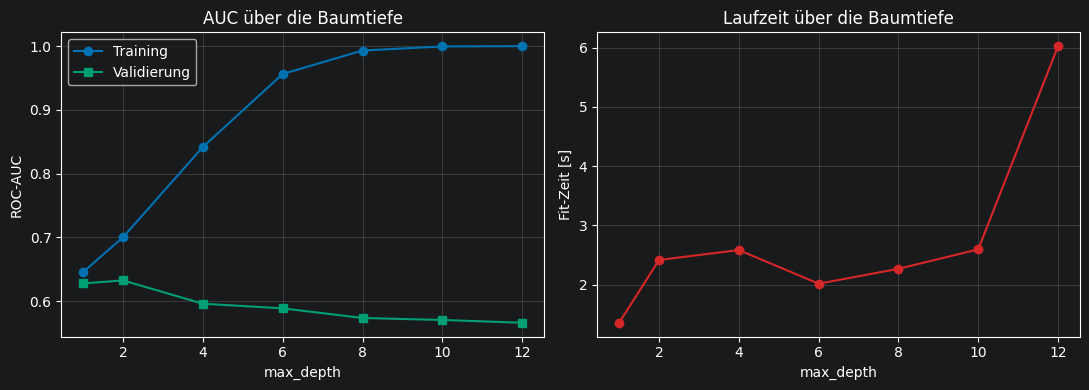

In [22]:
tiefen_tab = pd.DataFrame([e for e in experimente
                          if e["Konfiguration"].startswith("max_depth")
                          or e["Konfiguration"] == "Referenz"]).copy()
tiefen_tab["tiefe"] = tiefen_tab["Konfiguration"].str.extract(r"(\d+)").astype(float)
tiefen_tab.loc[tiefen_tab["Konfiguration"] == "Referenz", "tiefe"] = REF_PARAMS["max_depth"]
tiefen_tab = tiefen_tab.sort_values("tiefe")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(tiefen_tab["tiefe"], tiefen_tab["AUC Train"], marker="o", label="Training")
ax1.plot(tiefen_tab["tiefe"], tiefen_tab["AUC Val"], marker="s", label="Validierung")
ax1.set_xlabel("max_depth")
ax1.set_ylabel("ROC-AUC")
ax1.set_title("AUC über die Baumtiefe")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(tiefen_tab["tiefe"], tiefen_tab["Zeit [s]"], marker="o", color="tab:red")
ax2.set_xlabel("max_depth")
ax2.set_ylabel("Fit-Zeit [s]")
ax2.set_title("Laufzeit über die Baumtiefe")
ax2.grid(alpha=0.3)

fig.tight_layout()
save_fig(fig, "06_komplexitaetsreihe")
plt.show()

### Methodisches Gegenbeispiel: Leakage durch Duplikate vor dem Split

Das kostet fast nichts und ist trotzdem das wichtigste Experiment des Abschnitts. Werden
Zeilen dupliziert (etwa durch Oversampling der Minderheitsklasse), *bevor* der Split in
Trainings- und Validierungsdaten erfolgt, landen identische Beobachtungen in beiden
Teilmengen. Das Modell muss sie dann nicht generalisieren, sondern nur wiedererkennen.

Der Validierungswert steigt dadurch deutlich — er misst aber nichts mehr. Damit die
Memorierung überhaupt möglich ist, wird hier ein sehr flexibles Modell verwendet
(`max_depth=10`, `min_child_weight=1`); dasselbe Modell läuft zum Vergleich auf dem
sauberen Split.

Dieselbe Logik gilt für jede Vorverarbeitung, die die Zielvariable verwendet: würde das
Target-Encoding aus Schritt 2 einmal vorab auf allen Daten gefittet statt innerhalb der
Pipeline pro Fold, wäre der Effekt derselbe, nur subtiler.

In [23]:
LEAK_PARAMS = dict(n_estimators=300, learning_rate=0.1,
                   max_depth=10, min_child_weight=1)

# FALSCH: erst duplizieren, dann splitten
idx_dup = X_exp.sample(frac=0.5, random_state=RANDOM_STATE).index
X_leak = pd.concat([X_exp, X_exp.loc[idx_dup]])
y_leak = pd.concat([y_exp, y_exp.loc[idx_dup]])

X_lk_tr, X_lk_val, y_lk_tr, y_lk_val = train_test_split(
    X_leak, y_leak, test_size=0.25, stratify=y_leak, random_state=RANDOM_STATE,
)

modell_leak = baue_pipeline(**LEAK_PARAMS).fit(X_lk_tr, y_lk_tr)
auc_leak = roc_auc_score(y_lk_val, modell_leak.predict_proba(X_lk_val)[:, 1])

# RICHTIG: sauberer Split, gleiches Modell
modell_sauber = baue_pipeline(**LEAK_PARAMS).fit(X_exp_tr, y_exp_tr)
auc_sauber = roc_auc_score(y_exp_val, modell_sauber.predict_proba(X_exp_val)[:, 1])

anteil_dup = X_lk_val.index.isin(X_lk_tr.index).mean()

print(f"Anteil der Validierungszeilen, die auch im Training vorkommen: {anteil_dup:.1%}\n")
print(f"Val-AUC bei Duplikaten vor dem Split: {auc_leak:.4f}  <- wertlos")
print(f"Val-AUC bei sauberem Split:           {auc_sauber:.4f}  <- belastbar")
print(f"Scheinbarer Gewinn durch Leakage:     {auc_leak - auc_sauber:+.4f} AUC")

experimente.append({
    "Stufe": "M", "Konfiguration": "Duplikate vor dem Split",
    "Hypothese": "Validierungswert wird durch Memorierung aufgebläht",
    "AUC Train": np.nan, "AUC Val": auc_leak, "Gini Val": 2 * auc_leak - 1,
    "Abstand": np.nan, "Zeit [s]": np.nan,
})

C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Anteil der Validierungszeilen, die auch im Training vorkommen: 49.9%

Val-AUC bei Duplikaten vor dem Split: 0.8013  <- wertlos
Val-AUC bei sauberem Split:           0.5610  <- belastbar
Scheinbarer Gewinn durch Leakage:     +0.2403 AUC


### Zusammenfassung der Experimente

In [24]:
exp_tab = pd.DataFrame(experimente)

save_table(exp_tab, "07_experimente")
exp_tab.round(4)

gespeichert: xgboost_anwendung_abbildungen\07_experimente.csv


,Stufe,Konfiguration,Hypothese,AUC Train,AUC Val,Gini Val,Abstand,Zeit [s]
0,0,Referenz,Vergleichspunkt für alle weiteren Läufe,0.8419,0.5959,0.1918,0.2460,2.5830
1,0,gamma = 1000,kein Split erfüllt die Gain-Schwelle,0.5000,0.5000,0.0000,0.0000,1.5025
2,0,min_child_weight = 1e6,kein Blatt erreicht die Hessian-Schwelle,0.5000,0.5000,0.0000,0.0000,1.8518
3,0,reg_lambda = 1e6,Blattgewichte werden gegen null gedrückt,0.5936,0.5943,0.1886,-0.0007,1.8574
4,0,max_depth = 1,additives Modell ohne Feature-Interaktionen,0.6457,0.6279,0.2557,0.0178,1.3551
5,1,learning_rate = 0.001,"Underfit, Training zu früh abgeschnitten",0.6424,0.6188,0.2376,0.0236,1.8850
6,1,learning_rate = 1.0,"instabiles Training, überspringt Optimum",0.9838,0.5181,0.0362,0.4657,1.8397
7,1,subsample = 0.05,sehr wenige Beobachtungen je Baum,0.6546,0.5725,0.1450,0.0821,1.9011
8,1,colsample_bytree = 0.05,sehr wenige Features je Baum,0.7280,0.6121,0.2241,0.1159,1.6923
9,1,scale_pos_weight = 26,"AUC unverändert, Wahrscheinlichkeiten verschoben",0.8858,0.5827,0.1653,0.3031,1.7164


gespeichert: xgboost_anwendung_abbildungen\08_experimente_uebersicht.pdf | xgboost_anwendung_abbildungen\08_experimente_uebersicht.png


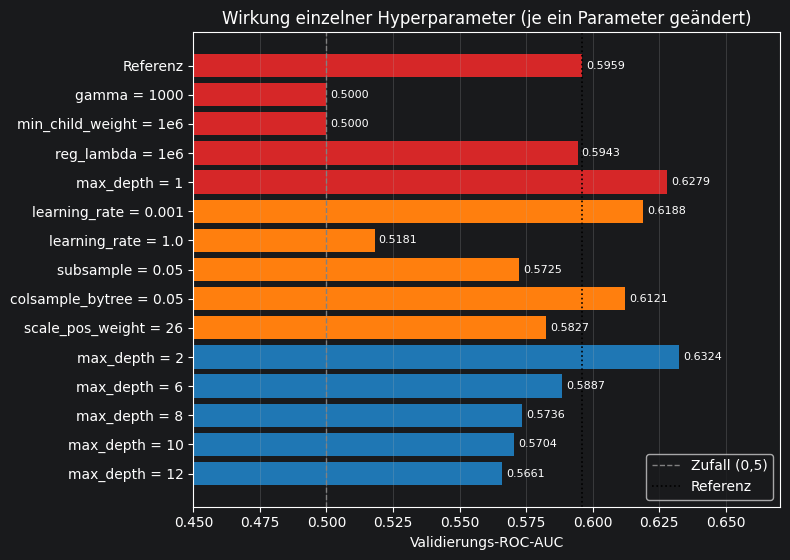

In [25]:
plot_tab = exp_tab[exp_tab["Stufe"] != "M"].copy()
farben = {0: "tab:red", 1: "tab:orange", 2: "tab:blue"}

fig, ax = plt.subplots(figsize=(8, max(4, 0.38 * len(plot_tab))))
balken = ax.barh(plot_tab["Konfiguration"][::-1], plot_tab["AUC Val"][::-1],
                 color=[farben[s] for s in plot_tab["Stufe"][::-1]])
ax.bar_label(balken, fmt="%.4f", padding=3, fontsize=8)

auc_ref = plot_tab.loc[plot_tab["Konfiguration"] == "Referenz", "AUC Val"].iloc[0]
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, label="Zufall (0,5)")
ax.axvline(auc_ref, color="black", linestyle=":", linewidth=1.2, label="Referenz")

ax.set_xlim(0.45, max(0.66, plot_tab["AUC Val"].max() * 1.06))
ax.set_xlabel("Validierungs-ROC-AUC")
ax.set_title("Wirkung einzelner Hyperparameter (je ein Parameter geändert)")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()

save_fig(fig, "08_experimente_uebersicht")
plt.show()

### Was folgt daraus für den Suchraum

Die Experimente liefern die Begründung für die Grenzen in Schritt 4:

* **`max_depth`** wird nach oben begrenzt, weil die Komplexitätsreihe zeigt, ab wo der
  Abstand zwischen Train und Validierung ohne Gegenleistung wächst.
* **`min_child_weight`** bekommt einen breiten Bereich, weil Stufe 0 gezeigt hat, wie
  stark dieser Parameter bei 3,6 % Positivrate durchgreift. Die absolute Obergrenze ist
  durch die Hessian-Summe im Wurzelknoten gegeben.
* **`learning_rate`** wird nach unten begrenzt, weil 0,001 bei realistischen Baumzahlen
  nicht auskonvergiert, und nach oben, weil 1,0 instabil ist.
* **`gamma`**, **`reg_alpha`** und **`reg_lambda`** werden logarithmisch gezogen. Die
  Stufe-0-Läufe zeigen, dass diese Parameter über mehrere Größenordnungen wirken; eine
  gleichverteilte Ziehung auf `[0, 10]` würde den interessanten Bereich unterhalb von 1
  kaum abdecken.
* **`scale_pos_weight`** kommt nicht in den Suchraum. Der Effekt auf die AUC war
  vernachlässigbar, die Verzerrung der Wahrscheinlichkeiten dagegen erheblich.

## Schritt 4: Suchraum der Hyperparameter

Für die Optimierung wird eine Zufallssuche (`RandomizedSearchCV`) verwendet. Gegenüber
einer vollständigen Gittersuche hat sie den Vorteil, dass die Anzahl der Durchläufe frei
wählbar ist und der Suchraum trotzdem breit abgedeckt wird.

Zu den einzelnen Parametern:

* **`n_estimators`** und **`learning_rate`** hängen zusammen: viele Bäume bei kleiner
  Lernrate liefern in der Regel bessere, aber langsamere Modelle. Da hier ohne Early
  Stopping gearbeitet wird, gehören beide gemeinsam in den Suchraum.
* **`max_depth`** steuert die Komplexität einzelner Bäume. Bei schwachem Signal sind
  flache Bäume oft besser, da tiefe Bäume schnell Rauschen anpassen — vgl. die
  Komplexitätsreihe in Schritt 3.
* **`min_child_weight`** begrenzt die minimale Summe der Instanzgewichte pro Blatt. Bei
  3,6 % Positivrate ist das einer der wichtigsten Regularisierungshebel — es verhindert,
  dass Blätter auf einer Handvoll positiver Fälle entstehen.
* **`subsample`** und **`colsample_bytree`** führen Zufall in Zeilen- und Spaltenauswahl
  ein und wirken ebenfalls regularisierend.
* **`gamma`**, **`reg_alpha`**, **`reg_lambda`** sind explizite Regularisierungsterme.
  Sie werden logarithmisch gezogen, damit auch der Bereich unterhalb von 1 ausreichend
  häufig getroffen wird.

In [26]:
param_dist = {
    "model__n_estimators":     randint(200, 1200),
    "model__learning_rate":    loguniform(0.01, 0.3),
    "model__max_depth":        randint(2, 9),
    "model__min_child_weight": randint(1, 50),
    "model__subsample":        uniform(0.5, 0.5),   # -> [0.5, 1.0]
    "model__colsample_bytree": uniform(0.5, 0.5),   # -> [0.5, 1.0]
    "model__gamma":            loguniform(1e-3, 5.0),
    "model__reg_alpha":        loguniform(1e-3, 5.0),
    "model__reg_lambda":       loguniform(1e-2, 20.0),
}

for name, verteilung_p in param_dist.items():
    print(f"{name:<28} {verteilung_p}")

model__n_estimators          <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000024E5B452660>
model__learning_rate         <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000024E5B4517F0>
model__max_depth             <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000024E840B9E50>
model__min_child_weight      <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000024E840B9D10>
model__subsample             <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000024E840BA0D0>
model__colsample_bytree      <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000024E840BA350>
model__gamma                 <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000024E7E274B00>
model__reg_alpha             <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000024E7E275810>
model__reg_lambda            <scipy.stats._distn_infrastructure.rv_continuous_frozen o

### Suche auf einer Teilmenge

Bei rund 476.000 Trainingszeilen ist eine Suche auf allen Daten unnötig teuer. Sie läuft
deshalb auf einer stratifizierten Teilmenge.

Die Annahme dahinter: die *Rangfolge* der Parameterkombinationen bleibt bei reduzierter
Datenmenge weitgehend erhalten, auch wenn das absolute Niveau der Metrik etwas niedriger
ausfällt. Das ist eine pragmatische Annahme und zugleich eine Grenze dieses Vorgehens.

Eine grobe Vorabschätzung der Laufzeit lässt sich aus den Fit-Zeiten in Schritt 3
ableiten: die Referenzkonfiguration lief dort auf `EXP_FRAC × 0,75` der Trainingsdaten.
Verlässlicher ist aber ohnehin die Ausgabe von `verbose=2` nach den ersten Fits.

In [27]:
if SEARCH_FRAC < 1.0:
    X_search, _, y_search, _ = train_test_split(
        X_train, y_train, train_size=SEARCH_FRAC,
        stratify=y_train, random_state=RANDOM_STATE,
    )
else:
    X_search, y_search = X_train, y_train

print(f"Suchdatensatz: {X_search.shape[0]:,} Zeilen ({SEARCH_FRAC:.0%})")
print(f"Geplante Fits: {N_ITER} x {CV_SPLITS} = {N_ITER * CV_SPLITS}")

Suchdatensatz: 119,042 Zeilen (25%)
Geplante Fits: 30 x 3 = 90


## Schritt 5: Hyperparameter-Suche

Zwei technische Details:

* **`n_jobs`**: Die Parallelisierung liegt beim XGBoost-Modell (`n_jobs=-1`), die Suche
  läuft mit `n_jobs=1`. Setzt man beides auf `-1`, konkurrieren die Prozesse um dieselben
  Kerne, was die Laufzeit meist verschlechtert statt verbessert.
* **`refit=False`**: Ein automatischer Refit würde nur auf der Teilmenge erfolgen. Das
  finale Modell wird stattdessen in Schritt 6 bewusst auf allen Trainingsdaten trainiert.

`verbose=2` schreibt die Dauer jedes einzelnen Fits mit, da nach wenigen Fits lässt sich die
Gesamtdauer besser abschätzen als über jede Vorabrechnung.

In [28]:
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=baue_pipeline(),
    param_distributions=param_dist,
    n_iter=N_ITER,
    scoring="roc_auc",
    cv=cv,
    refit=False,
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=2,
    return_train_score=True,
)

t0 = time.perf_counter()
search.fit(X_search, y_search)
such_zeit = time.perf_counter() - t0

print(f"\nDauer der Suche: {such_zeit / 60:.1f} min")
print(f"Bester CV-AUC (auf der Teilmenge): {search.best_score_:.4f} "
      f"(Gini {2 * search.best_score_ - 1:.4f})\n")
print("Beste Parameter:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k.replace('model__', ''):<20} {v}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6872700594236812, model__gamma=3.2859708169642414, model__learning_rate=0.1205712628744377, model__max_depth=6, model__min_child_weight=21, model__n_estimators=814, model__reg_alpha=0.04457814368987925, model__reg_lambda=0.02138061513134765, model__subsample=0.7296244459829335; total time=   5.9s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6872700594236812, model__gamma=3.2859708169642414, model__learning_rate=0.1205712628744377, model__max_depth=6, model__min_child_weight=21, model__n_estimators=814, model__reg_alpha=0.04457814368987925, model__reg_lambda=0.02138061513134765, model__subsample=0.7296244459829335; total time=   8.1s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6872700594236812, model__gamma=3.2859708169642414, model__learning_rate=0.1205712628744377, model__max_depth=6, model__min_child_weight=21, model__n_estimators=814, model__reg_alpha=0.04457814368987925, model__reg_lambda=0.02138061513134765, model__subsample=0.7296244459829335; total time=   5.4s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6668543055695109, model__gamma=0.00337644806595081, model__learning_rate=0.09150423569345205, model__max_depth=6, model__min_child_weight=2, model__n_estimators=543, model__reg_alpha=1.1999975480350795, model__reg_lambda=0.05022706182399988, model__subsample=0.5909124836035503; total time=   5.4s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6668543055695109, model__gamma=0.00337644806595081, model__learning_rate=0.09150423569345205, model__max_depth=6, model__min_child_weight=2, model__n_estimators=543, model__reg_alpha=1.1999975480350795, model__reg_lambda=0.05022706182399988, model__subsample=0.5909124836035503; total time=   5.3s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6668543055695109, model__gamma=0.00337644806595081, model__learning_rate=0.09150423569345205, model__max_depth=6, model__min_child_weight=2, model__n_estimators=543, model__reg_alpha=1.1999975480350795, model__reg_lambda=0.05022706182399988, model__subsample=0.5909124836035503; total time=   5.2s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.5917022549267169, model__gamma=0.01334697757417809, model__learning_rate=0.05958389350068958, model__max_depth=5, model__min_child_weight=25, model__n_estimators=760, model__reg_alpha=0.08732241283327245, model__reg_lambda=0.20890703332534774, model__subsample=0.5233328316068078; total time=   5.9s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.5917022549267169, model__gamma=0.01334697757417809, model__learning_rate=0.05958389350068958, model__max_depth=5, model__min_child_weight=25, model__n_estimators=760, model__reg_alpha=0.08732241283327245, model__reg_lambda=0.20890703332534774, model__subsample=0.5233328316068078; total time=   6.1s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.5917022549267169, model__gamma=0.01334697757417809, model__learning_rate=0.05958389350068958, model__max_depth=5, model__min_child_weight=25, model__n_estimators=760, model__reg_alpha=0.08732241283327245, model__reg_lambda=0.20890703332534774, model__subsample=0.5233328316068078; total time=   6.1s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.9868777594207296, model__gamma=0.007261297093317892, model__learning_rate=0.013609328284484965, model__max_depth=7, model__min_child_weight=44, model__n_estimators=766, model__reg_alpha=4.334525417040867, model__reg_lambda=0.3473748013859436, model__subsample=0.9299702033681603; total time=   7.2s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.9868777594207296, model__gamma=0.007261297093317892, model__learning_rate=0.013609328284484965, model__max_depth=7, model__min_child_weight=44, model__n_estimators=766, model__reg_alpha=4.334525417040867, model__reg_lambda=0.3473748013859436, model__subsample=0.9299702033681603; total time=   7.6s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.9868777594207296, model__gamma=0.007261297093317892, model__learning_rate=0.013609328284484965, model__max_depth=7, model__min_child_weight=44, model__n_estimators=766, model__reg_alpha=4.334525417040867, model__reg_lambda=0.3473748013859436, model__subsample=0.9299702033681603; total time=   8.0s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8401537692938899, model__gamma=0.046385604424045254, model__learning_rate=0.010461499920091565, model__max_depth=2, model__min_child_weight=14, model__n_estimators=441, model__reg_alpha=0.026646739856563358, model__reg_lambda=0.01129028948611657, model__subsample=0.6154469128110744; total time=   3.4s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8401537692938899, model__gamma=0.046385604424045254, model__learning_rate=0.010461499920091565, model__max_depth=2, model__min_child_weight=14, model__n_estimators=441, model__reg_alpha=0.026646739856563358, model__reg_lambda=0.01129028948611657, model__subsample=0.6154469128110744; total time=   3.8s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8401537692938899, model__gamma=0.046385604424045254, model__learning_rate=0.010461499920091565, model__max_depth=2, model__min_child_weight=14, model__n_estimators=441, model__reg_alpha=0.026646739856563358, model__reg_lambda=0.01129028948611657, model__subsample=0.6154469128110744; total time=   4.9s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6205127330130058, model__gamma=0.3367993628137755, model__learning_rate=0.07962309016748462, model__max_depth=8, model__min_child_weight=35, model__n_estimators=405, model__reg_alpha=0.027958988618089223, model__reg_lambda=0.039954600454124516, model__subsample=0.8776807051588262; total time=   5.1s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6205127330130058, model__gamma=0.3367993628137755, model__learning_rate=0.07962309016748462, model__max_depth=8, model__min_child_weight=35, model__n_estimators=405, model__reg_alpha=0.027958988618089223, model__reg_lambda=0.039954600454124516, model__subsample=0.8776807051588262; total time=   5.8s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6205127330130058, model__gamma=0.3367993628137755, model__learning_rate=0.07962309016748462, model__max_depth=8, model__min_child_weight=35, model__n_estimators=405, model__reg_alpha=0.027958988618089223, model__reg_lambda=0.039954600454124516, model__subsample=0.8776807051588262; total time=   5.5s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7125779372456224, model__gamma=0.00587719328338131, model__learning_rate=0.06895443757896232, model__max_depth=6, model__min_child_weight=18, model__n_estimators=929, model__reg_alpha=0.0460921587133052, model__reg_lambda=0.20155927234884677, model__subsample=0.9633294328968971; total time=   9.0s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7125779372456224, model__gamma=0.00587719328338131, model__learning_rate=0.06895443757896232, model__max_depth=6, model__min_child_weight=18, model__n_estimators=929, model__reg_alpha=0.0460921587133052, model__reg_lambda=0.20155927234884677, model__subsample=0.9633294328968971; total time=   8.4s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7125779372456224, model__gamma=0.00587719328338131, model__learning_rate=0.06895443757896232, model__max_depth=6, model__min_child_weight=18, model__n_estimators=929, model__reg_alpha=0.0460921587133052, model__reg_lambda=0.20155927234884677, model__subsample=0.9633294328968971; total time=   8.1s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8636359979282104, model__gamma=0.016138549885357872, model__learning_rate=0.06960091021987622, model__max_depth=5, model__min_child_weight=40, model__n_estimators=924, model__reg_alpha=0.02739716567160666, model__reg_lambda=0.07865589790890784, model__subsample=0.9143687545759647; total time=   7.5s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8636359979282104, model__gamma=0.016138549885357872, model__learning_rate=0.06960091021987622, model__max_depth=5, model__min_child_weight=40, model__n_estimators=924, model__reg_alpha=0.02739716567160666, model__reg_lambda=0.07865589790890784, model__subsample=0.9143687545759647; total time=   7.3s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8636359979282104, model__gamma=0.016138549885357872, model__learning_rate=0.06960091021987622, model__max_depth=5, model__min_child_weight=40, model__n_estimators=924, model__reg_alpha=0.02739716567160666, model__reg_lambda=0.07865589790890784, model__subsample=0.9143687545759647; total time=   7.2s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6783766633467947, model__gamma=0.010943804457233497, model__learning_rate=0.06333268775321843, model__max_depth=2, model__min_child_weight=29, model__n_estimators=214, model__reg_alpha=0.004086179590830547, model__reg_lambda=0.011262018792004667, model__subsample=0.7117007403531848; total time=   1.9s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6783766633467947, model__gamma=0.010943804457233497, model__learning_rate=0.06333268775321843, model__max_depth=2, model__min_child_weight=29, model__n_estimators=214, model__reg_alpha=0.004086179590830547, model__reg_lambda=0.011262018792004667, model__subsample=0.7117007403531848; total time=   1.9s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6783766633467947, model__gamma=0.010943804457233497, model__learning_rate=0.06333268775321843, model__max_depth=2, model__min_child_weight=29, model__n_estimators=214, model__reg_alpha=0.004086179590830547, model__reg_lambda=0.011262018792004667, model__subsample=0.7117007403531848; total time=   2.0s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6974407590877849, model__gamma=0.012178784754697521, model__learning_rate=0.010490534235091775, model__max_depth=4, model__min_child_weight=17, model__n_estimators=591, model__reg_alpha=0.4972509797814939, model__reg_lambda=3.51549552284454, model__subsample=0.5370223258670452; total time=   4.9s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6974407590877849, model__gamma=0.012178784754697521, model__learning_rate=0.010490534235091775, model__max_depth=4, model__min_child_weight=17, model__n_estimators=591, model__reg_alpha=0.4972509797814939, model__reg_lambda=3.51549552284454, model__subsample=0.5370223258670452; total time=   4.7s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6974407590877849, model__gamma=0.012178784754697521, model__learning_rate=0.010490534235091775, model__max_depth=4, model__min_child_weight=17, model__n_estimators=591, model__reg_alpha=0.4972509797814939, model__reg_lambda=3.51549552284454, model__subsample=0.5370223258670452; total time=   5.0s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6792328642721364, model__gamma=0.002682848665467022, model__learning_rate=0.18832519048593593, model__max_depth=5, model__min_child_weight=34, model__n_estimators=232, model__reg_alpha=0.0017183057019185925, model__reg_lambda=0.1063070268375106, model__subsample=0.6625916610133735; total time=   2.5s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6792328642721364, model__gamma=0.002682848665467022, model__learning_rate=0.18832519048593593, model__max_depth=5, model__min_child_weight=34, model__n_estimators=232, model__reg_alpha=0.0017183057019185925, model__reg_lambda=0.1063070268375106, model__subsample=0.6625916610133735; total time=   2.6s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6792328642721364, model__gamma=0.002682848665467022, model__learning_rate=0.18832519048593593, model__max_depth=5, model__min_child_weight=34, model__n_estimators=232, model__reg_alpha=0.0017183057019185925, model__reg_lambda=0.1063070268375106, model__subsample=0.6625916610133735; total time=   3.0s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.864803089169032, model__gamma=0.22819491501562741, model__learning_rate=0.20441878352493792, model__max_depth=2, model__min_child_weight=35, model__n_estimators=812, model__reg_alpha=3.929469242189592, model__reg_lambda=6.342931154488705, model__subsample=0.8608647605824367; total time=   5.3s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.864803089169032, model__gamma=0.22819491501562741, model__learning_rate=0.20441878352493792, model__max_depth=2, model__min_child_weight=35, model__n_estimators=812, model__reg_alpha=3.929469242189592, model__reg_lambda=6.342931154488705, model__subsample=0.8608647605824367; total time=   5.2s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.864803089169032, model__gamma=0.22819491501562741, model__learning_rate=0.20441878352493792, model__max_depth=2, model__min_child_weight=35, model__n_estimators=812, model__reg_alpha=3.929469242189592, model__reg_lambda=6.342931154488705, model__subsample=0.8608647605824367; total time=   5.1s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6179924598744779, model__gamma=0.008855009775264168, model__learning_rate=0.011474276591948267, model__max_depth=8, model__min_child_weight=15, model__n_estimators=1057, model__reg_alpha=0.0012417226051008223, model__reg_lambda=0.022706638025961814, model__subsample=0.5157145928433671; total time=  10.9s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6179924598744779, model__gamma=0.008855009775264168, model__learning_rate=0.011474276591948267, model__max_depth=8, model__min_child_weight=15, model__n_estimators=1057, model__reg_alpha=0.0012417226051008223, model__reg_lambda=0.022706638025961814, model__subsample=0.5157145928433671; total time=  10.9s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6179924598744779, model__gamma=0.008855009775264168, model__learning_rate=0.011474276591948267, model__max_depth=8, model__min_child_weight=15, model__n_estimators=1057, model__reg_alpha=0.0012417226051008223, model__reg_lambda=0.022706638025961814, model__subsample=0.5157145928433671; total time=  12.0s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8182052056318903, model__gamma=0.014547666775759168, model__learning_rate=0.056392399916675585, model__max_depth=7, model__min_child_weight=37, model__n_estimators=606, model__reg_alpha=0.1720765760893332, model__reg_lambda=0.6053849711576973, model__subsample=0.6015306123673847; total time=   6.4s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8182052056318903, model__gamma=0.014547666775759168, model__learning_rate=0.056392399916675585, model__max_depth=7, model__min_child_weight=37, model__n_estimators=606, model__reg_alpha=0.1720765760893332, model__reg_lambda=0.6053849711576973, model__subsample=0.6015306123673847; total time=   6.9s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8182052056318903, model__gamma=0.014547666775759168, model__learning_rate=0.056392399916675585, model__max_depth=7, model__min_child_weight=37, model__n_estimators=606, model__reg_alpha=0.1720765760893332, model__reg_lambda=0.6053849711576973, model__subsample=0.6015306123673847; total time=   6.4s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.9714267852789905, model__gamma=0.164129027861976, model__learning_rate=0.10623841728427216, model__max_depth=5, model__min_child_weight=2, model__n_estimators=881, model__reg_alpha=0.9754680378833334, model__reg_lambda=1.2327777848130477, model__subsample=0.9357302950938589; total time=   7.3s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.9714267852789905, model__gamma=0.164129027861976, model__learning_rate=0.10623841728427216, model__max_depth=5, model__min_child_weight=2, model__n_estimators=881, model__reg_alpha=0.9754680378833334, model__reg_lambda=1.2327777848130477, model__subsample=0.9357302950938589; total time=   7.4s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.9714267852789905, model__gamma=0.164129027861976, model__learning_rate=0.10623841728427216, model__max_depth=5, model__min_child_weight=2, model__n_estimators=881, model__reg_alpha=0.9754680378833334, model__reg_lambda=1.2327777848130477, model__subsample=0.9357302950938589; total time=   7.7s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.9018360384495572, model__gamma=0.004899108428855473, model__learning_rate=0.20816986844858934, model__max_depth=4, model__min_child_weight=28, model__n_estimators=672, model__reg_alpha=0.015006703959278904, model__reg_lambda=0.02308259884291957, model__subsample=0.6139675812709708; total time=   5.3s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.9018360384495572, model__gamma=0.004899108428855473, model__learning_rate=0.20816986844858934, model__max_depth=4, model__min_child_weight=28, model__n_estimators=672, model__reg_alpha=0.015006703959278904, model__reg_lambda=0.02308259884291957, model__subsample=0.6139675812709708; total time=   5.9s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.9018360384495572, model__gamma=0.004899108428855473, model__learning_rate=0.20816986844858934, model__max_depth=4, model__min_child_weight=28, model__n_estimators=672, model__reg_alpha=0.015006703959278904, model__reg_lambda=0.02308259884291957, model__subsample=0.6139675812709708; total time=   6.0s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7135538943131281, model__gamma=1.0612362645078426, model__learning_rate=0.18681142751959703, model__max_depth=8, model__min_child_weight=6, model__n_estimators=655, model__reg_alpha=0.09453241261359988, model__reg_lambda=0.39850913234024704, model__subsample=0.8462180164451352; total time=   5.3s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7135538943131281, model__gamma=1.0612362645078426, model__learning_rate=0.18681142751959703, model__max_depth=8, model__min_child_weight=6, model__n_estimators=655, model__reg_alpha=0.09453241261359988, model__reg_lambda=0.39850913234024704, model__subsample=0.8462180164451352; total time=   5.4s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7135538943131281, model__gamma=1.0612362645078426, model__learning_rate=0.18681142751959703, model__max_depth=8, model__min_child_weight=6, model__n_estimators=655, model__reg_alpha=0.09453241261359988, model__reg_lambda=0.39850913234024704, model__subsample=0.8462180164451352; total time=   5.9s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6347061668992607, model__gamma=0.007998581679820586, model__learning_rate=0.017725001286332035, model__max_depth=2, model__min_child_weight=49, model__n_estimators=1029, model__reg_alpha=3.9318122798867297, model__reg_lambda=15.033752280234232, model__subsample=0.6258911479126821; total time=   7.2s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6347061668992607, model__gamma=0.007998581679820586, model__learning_rate=0.017725001286332035, model__max_depth=2, model__min_child_weight=49, model__n_estimators=1029, model__reg_alpha=3.9318122798867297, model__reg_lambda=15.033752280234232, model__subsample=0.6258911479126821; total time=   7.3s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6347061668992607, model__gamma=0.007998581679820586, model__learning_rate=0.017725001286332035, model__max_depth=2, model__min_child_weight=49, model__n_estimators=1029, model__reg_alpha=3.9318122798867297, model__reg_lambda=15.033752280234232, model__subsample=0.6258911479126821; total time=   7.5s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7486242529461927, model__gamma=0.012969996024538197, model__learning_rate=0.02634777514406047, model__max_depth=2, model__min_child_weight=49, model__n_estimators=201, model__reg_alpha=0.07234268585962396, model__reg_lambda=0.014788798853215396, model__subsample=0.6393232321183058; total time=   2.1s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7486242529461927, model__gamma=0.012969996024538197, model__learning_rate=0.02634777514406047, model__max_depth=2, model__min_child_weight=49, model__n_estimators=201, model__reg_alpha=0.07234268585962396, model__reg_lambda=0.014788798853215396, model__subsample=0.6393232321183058; total time=   2.1s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7486242529461927, model__gamma=0.012969996024538197, model__learning_rate=0.02634777514406047, model__max_depth=2, model__min_child_weight=49, model__n_estimators=201, model__reg_alpha=0.07234268585962396, model__reg_lambda=0.014788798853215396, model__subsample=0.6393232321183058; total time=   2.1s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.9541329429833268, model__gamma=0.007693646851823215, model__learning_rate=0.01636919398042504, model__max_depth=5, model__min_child_weight=26, model__n_estimators=871, model__reg_alpha=0.11095195322989977, model__reg_lambda=0.9047105690021457, model__subsample=0.5404266631663577; total time=   8.5s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.9541329429833268, model__gamma=0.007693646851823215, model__learning_rate=0.01636919398042504, model__max_depth=5, model__min_child_weight=26, model__n_estimators=871, model__reg_alpha=0.11095195322989977, model__reg_lambda=0.9047105690021457, model__subsample=0.5404266631663577; total time=   8.8s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.9541329429833268, model__gamma=0.007693646851823215, model__learning_rate=0.01636919398042504, model__max_depth=5, model__min_child_weight=26, model__n_estimators=871, model__reg_alpha=0.11095195322989977, model__reg_lambda=0.9047105690021457, model__subsample=0.5404266631663577; total time=   8.8s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6848272280307022, model__gamma=0.007865790008296467, model__learning_rate=0.1535800500056149, model__max_depth=6, model__min_child_weight=34, model__n_estimators=397, model__reg_alpha=0.029870304482326006, model__reg_lambda=4.955256078201114, model__subsample=0.8991725624922755; total time=   4.5s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6848272280307022, model__gamma=0.007865790008296467, model__learning_rate=0.1535800500056149, model__max_depth=6, model__min_child_weight=34, model__n_estimators=397, model__reg_alpha=0.029870304482326006, model__reg_lambda=4.955256078201114, model__subsample=0.8991725624922755; total time=   4.4s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.6848272280307022, model__gamma=0.007865790008296467, model__learning_rate=0.1535800500056149, model__max_depth=6, model__min_child_weight=34, model__n_estimators=397, model__reg_alpha=0.029870304482326006, model__reg_lambda=4.955256078201114, model__subsample=0.8991725624922755; total time=   4.3s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.5753587719827147, model__gamma=0.07582493233133318, model__learning_rate=0.10661047693324774, model__max_depth=4, model__min_child_weight=20, model__n_estimators=963, model__reg_alpha=0.32084128751125357, model__reg_lambda=0.011343757160462292, model__subsample=0.7560465291496405; total time=   8.1s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.5753587719827147, model__gamma=0.07582493233133318, model__learning_rate=0.10661047693324774, model__max_depth=4, model__min_child_weight=20, model__n_estimators=963, model__reg_alpha=0.32084128751125357, model__reg_lambda=0.011343757160462292, model__subsample=0.7560465291496405; total time=   8.1s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.5753587719827147, model__gamma=0.07582493233133318, model__learning_rate=0.10661047693324774, model__max_depth=4, model__min_child_weight=20, model__n_estimators=963, model__reg_alpha=0.32084128751125357, model__reg_lambda=0.011343757160462292, model__subsample=0.7560465291496405; total time=   8.0s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.613247887598969, model__gamma=0.24348645087784815, model__learning_rate=0.01809507378721579, model__max_depth=2, model__min_child_weight=40, model__n_estimators=839, model__reg_alpha=0.08225204705637795, model__reg_lambda=5.825137581917712, model__subsample=0.8378450585196404; total time=   6.3s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.613247887598969, model__gamma=0.24348645087784815, model__learning_rate=0.01809507378721579, model__max_depth=2, model__min_child_weight=40, model__n_estimators=839, model__reg_alpha=0.08225204705637795, model__reg_lambda=5.825137581917712, model__subsample=0.8378450585196404; total time=   6.0s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.613247887598969, model__gamma=0.24348645087784815, model__learning_rate=0.01809507378721579, model__max_depth=2, model__min_child_weight=40, model__n_estimators=839, model__reg_alpha=0.08225204705637795, model__reg_lambda=5.825137581917712, model__subsample=0.8378450585196404; total time=   4.8s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8676080596203861, model__gamma=0.0059340288559074535, model__learning_rate=0.063064406141353, model__max_depth=3, model__min_child_weight=35, model__n_estimators=462, model__reg_alpha=0.276223859835716, model__reg_lambda=4.985112872145931, model__subsample=0.7776004057997312; total time=   3.4s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8676080596203861, model__gamma=0.0059340288559074535, model__learning_rate=0.063064406141353, model__max_depth=3, model__min_child_weight=35, model__n_estimators=462, model__reg_alpha=0.276223859835716, model__reg_lambda=4.985112872145931, model__subsample=0.7776004057997312; total time=   3.7s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8676080596203861, model__gamma=0.0059340288559074535, model__learning_rate=0.063064406141353, model__max_depth=3, model__min_child_weight=35, model__n_estimators=462, model__reg_alpha=0.276223859835716, model__reg_lambda=4.985112872145931, model__subsample=0.7776004057997312; total time=   3.7s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7648252891780032, model__gamma=0.007845206319942895, model__learning_rate=0.01372537052078299, model__max_depth=5, model__min_child_weight=5, model__n_estimators=236, model__reg_alpha=1.8401166635728765, model__reg_lambda=0.041968923045722084, model__subsample=0.6394356762960909; total time=   2.5s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7648252891780032, model__gamma=0.007845206319942895, model__learning_rate=0.01372537052078299, model__max_depth=5, model__min_child_weight=5, model__n_estimators=236, model__reg_alpha=1.8401166635728765, model__reg_lambda=0.041968923045722084, model__subsample=0.6394356762960909; total time=   3.0s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7648252891780032, model__gamma=0.007845206319942895, model__learning_rate=0.01372537052078299, model__max_depth=5, model__min_child_weight=5, model__n_estimators=236, model__reg_alpha=1.8401166635728765, model__reg_lambda=0.041968923045722084, model__subsample=0.6394356762960909; total time=   2.7s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8501789149863856, model__gamma=1.354484903617673, model__learning_rate=0.1840326214499077, model__max_depth=7, model__min_child_weight=33, model__n_estimators=1119, model__reg_alpha=1.4046198703146144, model__reg_lambda=12.261939836387764, model__subsample=0.8926703255569718; total time=   6.2s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8501789149863856, model__gamma=1.354484903617673, model__learning_rate=0.1840326214499077, model__max_depth=7, model__min_child_weight=33, model__n_estimators=1119, model__reg_alpha=1.4046198703146144, model__reg_lambda=12.261939836387764, model__subsample=0.8926703255569718; total time=   6.2s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8501789149863856, model__gamma=1.354484903617673, model__learning_rate=0.1840326214499077, model__max_depth=7, model__min_child_weight=33, model__n_estimators=1119, model__reg_alpha=1.4046198703146144, model__reg_lambda=12.261939836387764, model__subsample=0.8926703255569718; total time=   6.6s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8344941273571143, model__gamma=0.1405861036518071, model__learning_rate=0.0354737243708718, model__max_depth=2, model__min_child_weight=35, model__n_estimators=352, model__reg_alpha=0.0010440532432825318, model__reg_lambda=0.03394940766331566, model__subsample=0.7743668946832931; total time=   2.4s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8344941273571143, model__gamma=0.1405861036518071, model__learning_rate=0.0354737243708718, model__max_depth=2, model__min_child_weight=35, model__n_estimators=352, model__reg_alpha=0.0010440532432825318, model__reg_lambda=0.03394940766331566, model__subsample=0.7743668946832931; total time=   2.5s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8344941273571143, model__gamma=0.1405861036518071, model__learning_rate=0.0354737243708718, model__max_depth=2, model__min_child_weight=35, model__n_estimators=352, model__reg_alpha=0.0010440532432825318, model__reg_lambda=0.03394940766331566, model__subsample=0.7743668946832931; total time=   2.6s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8459475988463466, model__gamma=0.2579794680369433, model__learning_rate=0.021442378790951417, model__max_depth=2, model__min_child_weight=4, model__n_estimators=1000, model__reg_alpha=0.06712712356079406, model__reg_lambda=0.038931319816100186, model__subsample=0.6832343922914299; total time=   5.4s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8459475988463466, model__gamma=0.2579794680369433, model__learning_rate=0.021442378790951417, model__max_depth=2, model__min_child_weight=4, model__n_estimators=1000, model__reg_alpha=0.06712712356079406, model__reg_lambda=0.038931319816100186, model__subsample=0.6832343922914299; total time=   5.7s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8459475988463466, model__gamma=0.2579794680369433, model__learning_rate=0.021442378790951417, model__max_depth=2, model__min_child_weight=4, model__n_estimators=1000, model__reg_alpha=0.06712712356079406, model__reg_lambda=0.038931319816100186, model__subsample=0.6832343922914299; total time=   5.5s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8720852615282811, model__gamma=0.46423208680789474, model__learning_rate=0.02851301505515497, model__max_depth=5, model__min_child_weight=22, model__n_estimators=574, model__reg_alpha=0.008442105093228753, model__reg_lambda=0.8854853112762804, model__subsample=0.9894464291375045; total time=   4.4s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8720852615282811, model__gamma=0.46423208680789474, model__learning_rate=0.02851301505515497, model__max_depth=5, model__min_child_weight=22, model__n_estimators=574, model__reg_alpha=0.008442105093228753, model__reg_lambda=0.8854853112762804, model__subsample=0.9894464291375045; total time=   4.5s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.8720852615282811, model__gamma=0.46423208680789474, model__learning_rate=0.02851301505515497, model__max_depth=5, model__min_child_weight=22, model__n_estimators=574, model__reg_alpha=0.008442105093228753, model__reg_lambda=0.8854853112762804, model__subsample=0.9894464291375045; total time=   4.5s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7433710764797276, model__gamma=2.24715089858035, model__learning_rate=0.04381806045621311, model__max_depth=6, model__min_child_weight=30, model__n_estimators=808, model__reg_alpha=0.1361288465368478, model__reg_lambda=0.422489267162906, model__subsample=0.5976214938990223; total time=   6.6s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7433710764797276, model__gamma=2.24715089858035, model__learning_rate=0.04381806045621311, model__max_depth=6, model__min_child_weight=30, model__n_estimators=808, model__reg_alpha=0.1361288465368478, model__reg_lambda=0.422489267162906, model__subsample=0.5976214938990223; total time=   7.0s


C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END model__colsample_bytree=0.7433710764797276, model__gamma=2.24715089858035, model__learning_rate=0.04381806045621311, model__max_depth=6, model__min_child_weight=30, model__n_estimators=808, model__reg_alpha=0.1361288465368478, model__reg_lambda=0.422489267162906, model__subsample=0.5976214938990223; total time=   6.8s

Dauer der Suche: 9.5 min
Bester CV-AUC (auf der Teilmenge): 0.6236 (Gini 0.2472)

Beste Parameter:
  colsample_bytree     0.8344941273571143
  gamma                0.1405861036518071
  learning_rate        0.0354737243708718
  max_depth            2
  min_child_weight     35
  n_estimators         352
  reg_alpha            0.0010440532432825318
  reg_lambda           0.03394940766331566
  subsample            0.7743668946832931


### Ergebnisse der Suche

Aufschlussreich ist neben dem besten Wert vor allem die Streuung: liegen die besten zehn
Kombinationen dicht beieinander, ist das Modell gegenüber den Hyperparametern robust und
weitere Suche lohnt sich kaum.

In [29]:
cv_res = pd.DataFrame(search.cv_results_)

spalten = ["rank_test_score", "mean_test_score", "std_test_score", "mean_train_score"]
param_spalten = [c for c in cv_res.columns if c.startswith("param_")]

top10 = (cv_res.sort_values("rank_test_score")
               .head(10)[spalten + param_spalten]
               .reset_index(drop=True))
top10.columns = [c.replace("param_model__", "")
                  .replace("_test_score", "_test")
                  .replace("_train_score", "_train") for c in top10.columns]

save_table(top10.round(4), "09_suche_top10")
top10.round(4)

gespeichert: xgboost_anwendung_abbildungen\09_suche_top10.csv


,rank_test,mean_test,std_test,mean_train,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,subsample
0,1,0.6236,0.0063,0.6640,0.8345,0.1406,0.0355,2,35,352,0.0010,0.0339,0.7744
1,2,0.6235,0.0069,0.6646,0.6132,0.2435,0.0181,2,40,839,0.0823,5.8251,0.8378
2,3,0.6233,0.0065,0.7000,0.6974,0.0122,0.0105,4,17,591,0.4973,3.5155,0.5370
3,4,0.6230,0.0048,0.6636,0.6784,0.0109,0.0633,2,29,214,0.0041,0.0113,0.7117
4,5,0.6229,0.0066,0.7224,0.7648,0.0078,0.0137,5,5,236,1.8401,0.0420,0.6394
5,6,0.6223,0.0058,0.6643,0.6347,0.0080,0.0177,2,49,1029,3.9318,15.0338,0.6259
6,7,0.6221,0.0061,0.6479,0.8402,0.0464,0.0105,2,14,441,0.0266,0.0113,0.6154
7,8,0.6220,0.0059,0.6466,0.7486,0.0130,0.0263,2,49,201,0.0723,0.0148,0.6393
8,9,0.6200,0.0074,0.6815,0.8459,0.2580,0.0214,2,4,1000,0.0671,0.0389,0.6832
9,10,0.6177,0.0069,0.7833,0.9541,0.0077,0.0164,5,26,871,0.1110,0.9047,0.5404


### Welche Hyperparameter wirken?

Die Streudiagramme zeigen den Cross-Validation-Score gegen einzelne Hyperparameter. Ein
erkennbarer Trend deutet auf einen relevanten Parameter hin; eine reine Punktwolke
bedeutet, dass der Parameter im untersuchten Bereich kaum Einfluss hat.

*Einschränkung:* Es handelt sich um Randbetrachtungen — Wechselwirkungen zwischen
Parametern sind so nicht sichtbar. Genau das unterscheidet diese Darstellung von den
kontrollierten Einzelexperimenten in Schritt 3, wo jeweils nur ein Parameter variiert
wurde.

gespeichert: xgboost_anwendung_abbildungen\10_hyperparameter_einfluss.pdf | xgboost_anwendung_abbildungen\10_hyperparameter_einfluss.png


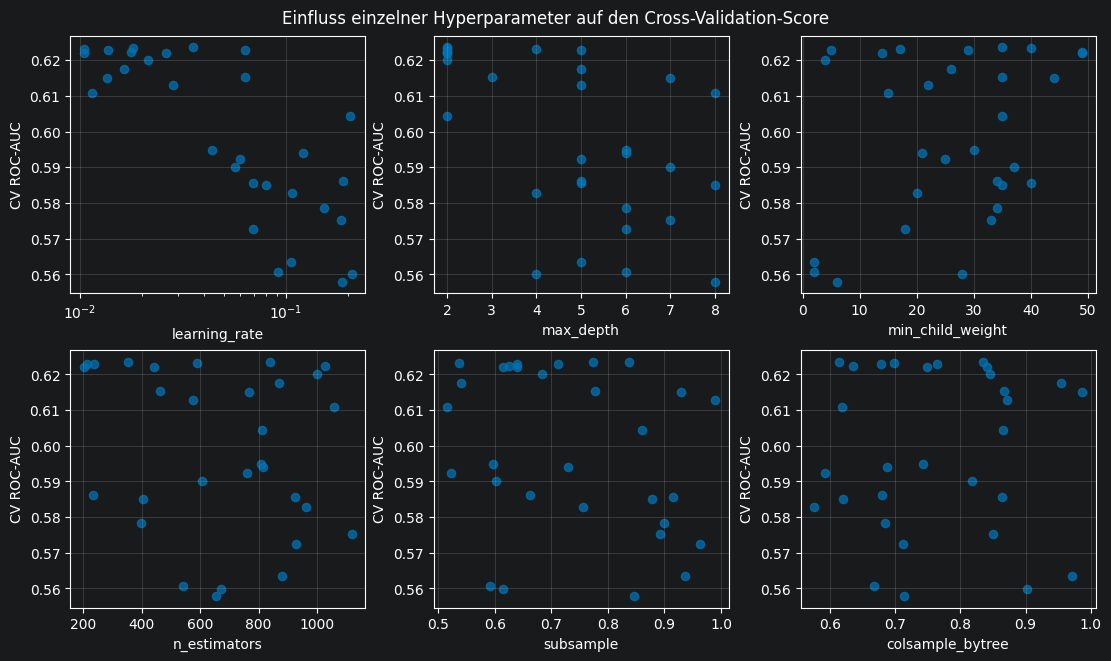

In [30]:
zu_plotten = ["learning_rate", "max_depth", "min_child_weight",
              "n_estimators", "subsample", "colsample_bytree"]

fig, axes = plt.subplots(2, 3, figsize=(11, 6.5), constrained_layout=True)

for ax, param in zip(axes.flat, zu_plotten):
    werte = cv_res[f"param_model__{param}"].astype(float)
    ax.scatter(werte, cv_res["mean_test_score"], alpha=0.75, s=35)
    ax.set_xlabel(param)
    ax.set_ylabel("CV ROC-AUC")
    ax.grid(alpha=0.3)
    if param == "learning_rate":
        ax.set_xscale("log")

fig.suptitle("Einfluss einzelner Hyperparameter auf den Cross-Validation-Score")

save_fig(fig, "10_hyperparameter_einfluss")
plt.show()

## Schritt 6: Finales Modell

Das beste Parameterset wird nun auf den **vollständigen** Trainingsdaten trainiert und auf
dem bis hierhin unberührten Testdatensatz bewertet.

`search.best_score_` stammt aus Schritt 5 aus einer
Cross-Validation auf einer Teilmenge und ist **nicht** direkt mit dem folgenden Testwert
vergleichbar.

In [31]:
beste_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
modell_final = baue_pipeline(**beste_params)

t0 = time.perf_counter()
modell_final.fit(X_train, y_train)
zeit_final = time.perf_counter() - t0

proba_final = modell_final.predict_proba(X_test)[:, 1]
auc_final = roc_auc_score(y_test, proba_final)
auc_final_train = roc_auc_score(y_train, modell_final.predict_proba(X_train)[:, 1])

print(f"Fit-Zeit: {zeit_final:.1f} s\n")
print(f"Train  AUC: {auc_final_train:.4f}")
print(f"Test   AUC: {auc_final:.4f} | Gini: {2 * auc_final - 1:.4f}")
print(f"Abstand Train-Test: {auc_final_train - auc_final:.4f}")
print(f"\nVeränderung gegenüber Standardparametern: "
      f"{auc_final - auc_standard:+.4f} AUC")

C:\Users\ericz\PycharmProjects\advanced-data-analytics\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Fit-Zeit: 14.2 s

Train  AUC: 0.6435
Test   AUC: 0.6396 | Gini: 0.2792
Abstand Train-Test: 0.0039

Veränderung gegenüber Standardparametern: +0.0263 AUC


### ROC-Kurven

Die Diagonale entspricht dem Zufallsmodell (AUC 0,5). Bei schwachem Signal liegen die
Kurven eng beieinander — für die Beurteilung ist weniger der optische Abstand relevant als
die Frage, ob der Unterschied größer ist als die Streuung der Cross-Validation
(`std_test` in der Tabelle oben).

gespeichert: xgboost_anwendung_abbildungen\11_roc_kurven.pdf | xgboost_anwendung_abbildungen\11_roc_kurven.png


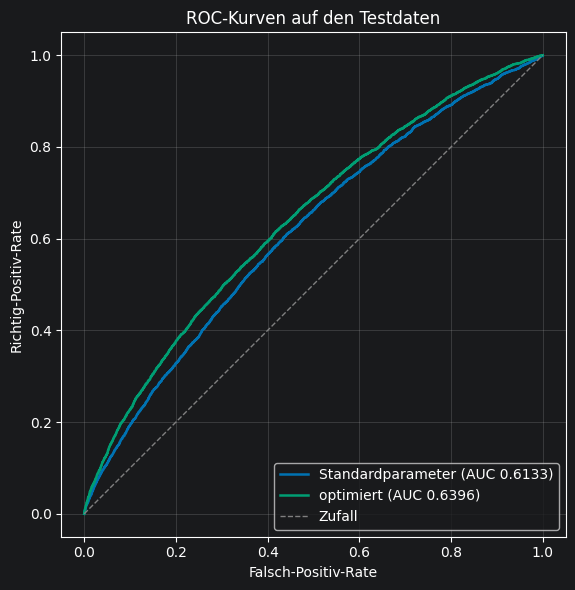

In [32]:
fig, ax = plt.subplots(figsize=(6, 6))

for label, proba in [("Standardparameter", proba_standard),
                     ("optimiert", proba_final)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, linewidth=1.8,
            label=f"{label} (AUC {roc_auc_score(y_test, proba):.4f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1, label="Zufall")
ax.set_xlabel("Falsch-Positiv-Rate")
ax.set_ylabel("Richtig-Positiv-Rate")
ax.set_title("ROC-Kurven auf den Testdaten")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
ax.set_aspect("equal")
fig.tight_layout()

save_fig(fig, "11_roc_kurven")
plt.show()

## Schritt 7: Feature Importance

Verwendet wird die **gain-basierte** Importance: sie misst, wie stark ein Feature zur
Reduktion der Verlustfunktion beiträgt. Alternativ bietet XGBoost `weight` (Anzahl der
Splits) und `cover` an, die andere Rangfolgen liefern — `plot_importance` aus der
XGBoost-Bibliothek nutzt standardmäßig `weight`.

Folgendes muss man beachten: Bei korrelierten Features verteilt sich der Beitrag auf mehrere Merkmale,
sodass einzelne Importances unterschätzt werden können. Die Werte sind daher eher als
Hinweis auf relevante Merkmalsgruppen zu lesen als als exakte Rangfolge.

gespeichert: xgboost_anwendung_abbildungen\12_feature_importance.pdf | xgboost_anwendung_abbildungen\12_feature_importance.png


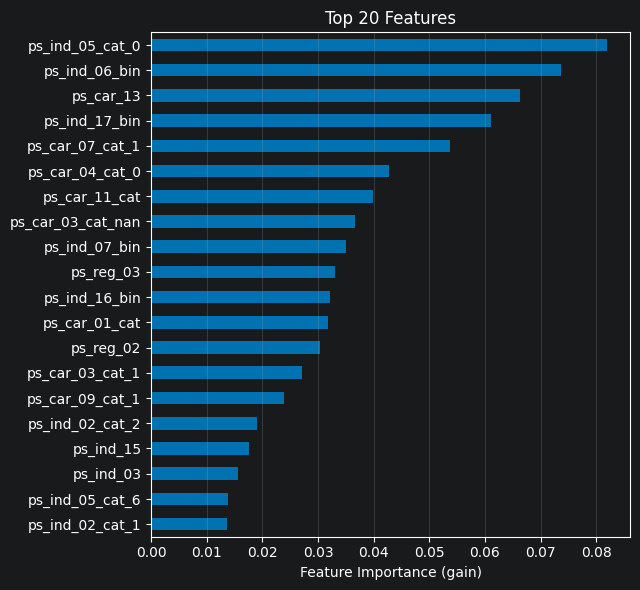

In [33]:
feat_names = modell_final.named_steps["prep"].get_feature_names_out()
importances = pd.Series(
    modell_final.named_steps["model"].feature_importances_, index=feat_names
).sort_values(ascending=False)

TOP_N = 20

fig, ax = plt.subplots(figsize=(6.5, 6))
importances.head(TOP_N)[::-1].plot.barh(ax=ax)
ax.set_xlabel("Feature Importance (gain)")
ax.set_title(f"Top {TOP_N} Features")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()

save_fig(fig, "12_feature_importance")
plt.show()

### Importance nach Merkmalsgruppen

Die Namenskonvention des Datensatzes unterteilt die Features in vier thematische Gruppen
(`ind`, `reg`, `car`, `calc`). Die aufsummierte Importance je Gruppe zeigt, welche
Themenbereiche das Modell tatsächlich nutzt.

In [34]:
gruppen = {praefix: [f for f in importances.index if f.startswith(praefix)]
           for praefix in ["ps_ind", "ps_reg", "ps_car", "ps_calc"]}

gruppen_tab = pd.DataFrame([
    {"Gruppe": g, "Anzahl Features": len(f),
     "Summe Importance": importances[f].sum(),
     "Anteil": importances[f].sum() / importances.sum()}
    for g, f in gruppen.items()
]).sort_values("Summe Importance", ascending=False).reset_index(drop=True)

save_table(gruppen_tab, "13_importance_nach_gruppe")
gruppen_tab.round(4)

gespeichert: xgboost_anwendung_abbildungen\13_importance_nach_gruppe.csv


,Gruppe,Anzahl Features,Summe Importance,Anteil
0,ps_ind,31,0.4298,0.4298
1,ps_car,41,0.4218,0.4218
2,ps_reg,3,0.0746,0.0746
3,ps_calc,20,0.0737,0.0737


## Ergebnisübersicht

Zur Einordnung: die Siegerlösungen der zugrundeliegenden Kaggle-Competition aus dem Jahr
2017 erreichten einen normalisierten Gini von rund 0,29. Ein sauberes Einzelmodell liegt
typischerweise im Bereich 0,26–0,28. Deutlich höhere Werte wären ein Warnsignal für Data
Leakage — wie das Duplikat-Experiment in Schritt 3 gezeigt hat, ist ein zu guter Wert
eher ein Grund zum Nachrechnen als zur Freude.

In [35]:
ergebnisse = pd.DataFrame([
    {"Konfiguration": "Standardparameter", "AUC Train": auc_standard_train,
     "AUC Test": auc_standard, "Gini Test": 2 * auc_standard - 1,
     "Fit-Zeit [s]": zeit_standard},
    {"Konfiguration": "optimiert", "AUC Train": auc_final_train,
     "AUC Test": auc_final, "Gini Test": 2 * auc_final - 1,
     "Fit-Zeit [s]": zeit_final},
])

save_table(ergebnisse, "14_ergebnisuebersicht")
ergebnisse.round(4)

gespeichert: xgboost_anwendung_abbildungen\14_ergebnisuebersicht.csv


,Konfiguration,AUC Train,AUC Test,Gini Test,Fit-Zeit [s]
0,Standardparameter,0.7724,0.6133,0.2266,10.0831
1,optimiert,0.6435,0.6396,0.2792,14.1911


In [36]:
params_tab = pd.DataFrame(
    sorted(beste_params.items()), columns=["Hyperparameter", "Wert"]
).astype(str)

save_table(params_tab, "15_beste_hyperparameter")
params_tab

gespeichert: xgboost_anwendung_abbildungen\15_beste_hyperparameter.csv


,Hyperparameter,Wert
0,colsample_bytree,0.8344941273571143
1,gamma,0.1405861036518071
2,learning_rate,0.0354737243708718
3,max_depth,2.0
4,min_child_weight,35.0
5,n_estimators,352.0
6,reg_alpha,0.0010440532432825318
7,reg_lambda,0.03394940766331566
8,subsample,0.7743668946832931


In [37]:
print("Inhalt von", ABB_DIR.resolve(), "\n")
for pfad in sorted(ABB_DIR.iterdir()):
    print(f"  {pfad.name:<40} {pfad.stat().st_size / 1024:>8.1f} KB")

Inhalt von C:\Users\ericz\ADA Projekt\xgboost_anwendung_abbildungen 

  01_zielverteilung.pdf                        14.3 KB
  01_zielverteilung.png                        70.2 KB
  02_feature_uebersicht.csv                     0.2 KB
  02_feature_uebersicht.tex                     0.4 KB
  03_fehlende_werte.pdf                        13.5 KB
  03_fehlende_werte.png                        67.8 KB
  04_scale_pos_weight.pdf                      21.5 KB
  04_scale_pos_weight.png                     135.5 KB
  04_suche_top10.csv                            0.9 KB
  04_suche_top10.tex                            1.3 KB
  05_hyperparameter_einfluss.pdf               23.3 KB
  05_hyperparameter_einfluss.png              259.7 KB
  05_overfitting_lernkurve.pdf                 20.0 KB
  05_overfitting_lernkurve.png                120.5 KB
  06_komplexitaetsreihe.pdf                    18.4 KB
  06_komplexitaetsreihe.png                   136.8 KB
  06_roc_kurven.pdf                            61.

## Grenzen und offene Punkte

* **Suche auf einer Teilmenge.** Ob die Rangfolge der Parameterkombinationen bei voller
  Datenmenge identisch bleibt, wurde nicht geprüft. Ein möglicher Test: die besten drei
  Kombinationen einmal auf allen Trainingsdaten cross-validieren.
* **Übertragbarkeit der Experimente.** Schritt 3 läuft auf einer Teilmenge und mit einer
  festen Referenzkonfiguration. Die dort beobachteten Effekte sind qualitativ belastbar,
  die absoluten Werte aber nicht mit den Ergebnissen aus Schritt 6 vergleichbar.
* **Einzelparameter-Betrachtung.** In Schritt 3 wird jeweils nur ein Parameter verändert.
  Wechselwirkungen — etwa zwischen `max_depth` und `min_child_weight` — bleiben dabei
  unsichtbar und werden erst in der Zufallssuche implizit mit abgedeckt.
* **Early Stopping** statt fester `n_estimators`: die Lernkurve in Schritt 3 zeigt, dass
  das Validierungsoptimum deutlich vor der letzten Runde liegt. Ein Suchlauf mit Early
  Stopping statt gezogener `n_estimators` wäre effizienter, erfordert aber ein
  vorverarbeitetes `eval_set` und damit einen Umbau der Pipeline-Logik.
* **Feature-Auswahl.** Die gruppierte Importance gibt einen Hinweis darauf, ob einzelne
  Merkmalsgruppen entfernt werden könnten. Ein direkter Vergleich mit und ohne steht aus.
* **Feature Engineering**, etwa die Anzahl fehlender Werte pro Zeile als eigenes Feature.